# 🏦 Tasa Personalizada por Perfil mediante Conceptos Dinámicos e IA
## Aplicación de Machine Learning y Deep Learning a Préstamos con Garantía Hipotecaria (PGH)

---

**PE en IA Aplicada a los Negocios:** Módulo de Deep Learning – CENTRUM PUCP  
**Tipo:** Trabajo Final – Módulo 4  
**Autor:** Hinojosa Garay, Ronaldiñho  
**Fecha:** Mayo 2026

---

### Tabla de contenidos
1. [Problema y oportunidad](#1)
2. [Planteamiento de la solución](#2)
3. [Configuración del entorno](#3)
4. [Carga y exploración del Dataset sintético](#4)
5. [Ingeniería de features](#5)
6. [Análisis Exploratorio de Datos (EDA)](#6)
7. [Preparación de datos para modelado](#7)
8. [Modelo 1: Machine Learning – Gradient Boosting (XGBoost)](#8)
9. [Modelo 2: Deep Learning – Red Neuronal Profunda (Keras)](#9)
10. [Modelo 3: Deep Learning Avanzado – Red con Embeddings Categóricos](#10)
11. [Comparación de modelos y selección](#11)
12. [Tarifario Dinámico: Generación de Tasa Personalizada por Perfil](#12)
13. [Análisis de valor para el negocio](#13)
14. [Conclusiones y recomendaciones](#14)


<a id="1"></a>
## 1. Problema y oportunidad

### 1.1 Contexto del negocio

Los **Préstamos con Garantía Hipotecaria (PGH)** son productos financieros donde el cliente ofrece un inmueble como colateral para acceder a financiamiento. La fijación de la **Tasa Efectiva Anual (TEA)** es una decisión crítica que impacta directamente en:

- **Competitividad comercial:** una tasa demasiado alta pierde clientes frente a la competencia.
- **Rentabilidad:** una tasa demasiado baja no compensa adecuadamente el riesgo asumido.
- **Gestión de riesgo:** la tasa debe reflejar la probabilidad real de deterioro del crédito.

### 1.2 Problema identificado

La fijación de tasas se basa actualmente en una **lógica predominantemente estática** (tarifarios por segmentos con rangos predefinidos y ajustes manuales por negociación), lo que resulta en:

| Problema | Descripción | Impacto |
|----------|-------------|---------|
| **Pérdida de conversión** | Perfiles de bajo riesgo reciben ofertas subóptimas | Pérdida de clientes valiosos |
| **Ineficiencia operativa** | Iteraciones y ajustes manuales constantes | Fricción, retrabajo, demoras |
| **Suboptimización del margen** | No se maximiza el margen ajustado por riesgo | Menor rentabilidad del portafolio |

### 1.3 Oportunidad

Aplicar **Machine Learning y Deep Learning** sobre la data histórica de desembolsos, perfiles de clientes y comportamiento de pago (cosechas), para construir un **tarifario dinámico personalizado** que asigne una tasa óptima a cada perfil individual, superando la lógica de "grupos/segmentos" estáticos.

### 1.4 Objetivo del proyecto

> **Desarrollar un modelo predictivo que, dado un perfil de cliente y las características de la operación, estime la tasa TEA final óptima ajustada por riesgo, generando un tarifario dinámico personalizado por perfil.**

La variable objetivo es `tasa_tea_final` y el enfoque es de **regresión**, donde el modelo aprende los patrones históricos que determinaron la tasa asignada, incorporando señales de riesgo derivadas del comportamiento de pago.


<a id="2"></a>
## 2. Planteamiento de la solución

### 2.1 Enfoque metodológico

```
┌─────────────────────────────────────────────────────────────────────┐
│                    PIPELINE DE SOLUCIÓN                            │
│                                                                     │
│  [Dataset PGH]  →  [Feature Engineering]  →  [EDA]                │
│                                                │                    │
│                                                ▼                    │
│                         ┌──────────────────────────────────┐       │
│                         │   MODELADO COMPARATIVO            │       │
│                         │                                    │       │
│                         │  ML: XGBoost (baseline)           │       │
│                         │  DL: Red Neuronal Profunda        │       │
│                         │  DL+: Embeddings Categóricos      │       │
│                         └──────────────┬───────────────────┘       │
│                                        │                            │
│                                        ▼                            │
│                         ┌──────────────────────────────────┐       │
│                         │   TARIFARIO DINÁMICO              │       │
│                         │   Tasa personalizada por perfil   │       │
│                         └──────────────────────────────────┘       │
└─────────────────────────────────────────────────────────────────────┘
```

### 2.2 Dataset

Se utiliza un **dataset sintético** de 3,800 contratos PGH desembolsados, con 160 columnas que incluyen:
- **Datos del contrato:** tipo, motivo, canal, plazo, monto, LTV, tasa
- **Perfil del cliente:** edad, género, estado civil, sector laboral, ingresos, score crediticio
- **Comportamiento de pago (cosechas):** días de atraso mes a mes (hasta 120 meses), PAR60
- **Variables de riesgo calculadas:** ratio cuota/ingreso, ratio deuda/ingreso, estado del crédito

### 2.3 Modelos a implementar

1. **XGBoost (Gradient Boosting):** Modelo de ML como baseline robusto para datos tabulares
2. **Red Neuronal Profunda (DNN):** Arquitectura fully-connected con regularización
3. **DNN con Embeddings Categóricos:** Aprovecha representaciones aprendidas de variables categóricas

### 2.4 Métricas de evaluación

- **MAE (Mean Absolute Error):** Error promedio en puntos porcentuales de TEA
- **RMSE (Root Mean Squared Error):** Penaliza errores grandes
- **R² (Coeficiente de Determinación):** Proporción de varianza explicada
- **MAPE (Mean Absolute Percentage Error):** Error relativo porcentual


<a id="3"></a>
## 3. Configuración del entorno


In [ ]:
# ============================================================
# 3.1 Instalación de dependencias
# ============================================================
!pip install -q xgboost shap

import warnings
warnings.filterwarnings('ignore')
print("✅ Dependencias instaladas correctamente")


✅ Dependencias instaladas correctamente


In [ ]:
# ============================================================
# 3.2 Importación de librerías
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# XGBoost
import xgboost as xgb

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks, regularizers, Model, Input

# SHAP para interpretabilidad
import shap

# Configuración de visualización
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14

# Semillas para reproducibilidad
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"NumPy: {np.__version__}")
print(f"Pandas: {pd.__version__}")
print(f"TensorFlow: {tf.__version__}")
print(f"XGBoost: {xgb.__version__}")
print("\n✅ Todas las librerías importadas correctamente")


NumPy: 2.0.2
Pandas: 2.2.2
TensorFlow: 2.20.0
XGBoost: 3.2.0

✅ Todas las librerías importadas correctamente


<a id="4"></a>
## 4. Carga y exploración del dataset sintético


In [ ]:
# ============================================================
# 4.1 Carga del dataset
# ============================================================
# En Google Colab, subir el archivo o montarlo desde Drive
# from google.colab import files
# uploaded = files.upload()

# Carga del CSV
df = pd.read_csv('pgh_dataset_sintetico.csv', sep=';', encoding='utf-8-sig')

print(f"📊 Dimensiones del dataset: {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"📅 Período: {df['fecha_desembolso'].min()} a {df['fecha_desembolso'].max()}")
print(f"💰 Rango de tasa TEA final: {df['tasa_tea_final'].min():.2f}% - {df['tasa_tea_final'].max():.2f}%")
print(f"📋 Tipos de contrato: {df['tipo_contrato'].unique().tolist()}")
print(f"📋 Tipos de crédito: {df['tipo_credito'].unique().tolist()}")


📊 Dimensiones del dataset: 3,800 filas × 160 columnas
📅 Período: 1/01/2019 a 9/12/2023
💰 Rango de tasa TEA final: 6.50% - 19.52%
📋 Tipos de contrato: ['cuota fija', 'cuota mixta', 'cuota puente']
📋 Tipos de crédito: ['NOR', 'RYA']


In [ ]:
# ============================================================
# 4.2 Estructura del dataset
# ============================================================
# Clasificamos las columnas por categoría funcional
cols_contrato = ['contrato_id', 'fecha_desembolso', 'tipo_contrato', 'tipo_credito',
                 'motivo_prestamo', 'canal_originacion']
cols_inmueble = ['zona', 'tipo_inmueble', 'valor_inmueble_soles', 'vive_en_inmueble']
cols_prestamo = ['loan_amount_soles', 'ltv', 'plazo_meses', 'tasa_tea_ofertada',
                 'descuento_negociacion_pp', 'tasa_tea_final', 'cuota_mensual_soles',
                 'ratio_cuota_ingreso']
cols_perfil = ['edad', 'genero', 'estado_civil', 'sector_laboral',
               'antiguedad_laboral_anios', 'ingreso_neto_mensual', 'score_crediticio',
               'numero_cuentas_activas', 'deuda_total_sistema_soles', 'ratio_deuda_ingreso',
               'numero_dependientes', 'tiene_garantia_adicional']
cols_comportamiento = ['duracion_efectiva_meses', 'meses_transcurridos', 'max_dias_atraso',
                       'meses_con_atraso', 'par60', 'estado_credito', 'prepago', 'refinanciado']
cols_cosechas = [c for c in df.columns if c.startswith('atraso_m')]

print("=" * 65)
print("ESTRUCTURA DEL DATASET PGH")
print("=" * 65)
print(f"{'Categoría':<30} {'# Columnas':>10}")
print("-" * 65)
print(f"{'Datos del contrato':<30} {len(cols_contrato):>10}")
print(f"{'Datos del inmueble':<30} {len(cols_inmueble):>10}")
print(f"{'Datos del préstamo':<30} {len(cols_prestamo):>10}")
print(f"{'Perfil del cliente':<30} {len(cols_perfil):>10}")
print(f"{'Comportamiento de pago':<30} {len(cols_comportamiento):>10}")
print(f"{'Cosechas (atraso por mes)':<30} {len(cols_cosechas):>10}")
print("-" * 65)
print(f"{'TOTAL':<30} {len(df.columns):>10}")


ESTRUCTURA DEL DATASET PGH
Categoría                      # Columnas
-----------------------------------------------------------------
Datos del contrato                      6
Datos del inmueble                      4
Datos del préstamo                      8
Perfil del cliente                     12
Comportamiento de pago                  8
Cosechas (atraso por mes)             120
-----------------------------------------------------------------
TOTAL                                 160


In [ ]:
# ============================================================
# 4.3 Estadísticas descriptivas de variables numéricas clave
# ============================================================
variables_clave = ['loan_amount_soles', 'ltv', 'plazo_meses', 'tasa_tea_final',
                   'ingreso_neto_mensual', 'score_crediticio', 'ratio_cuota_ingreso',
                   'ratio_deuda_ingreso', 'par60', 'edad', 'antiguedad_laboral_anios']

desc = df[variables_clave].describe().T
desc['cv'] = desc['std'] / desc['mean']  # Coeficiente de variación
print("\n📈 Estadísticas descriptivas de variables clave:\n")
display(desc.round(4))



📈 Estadísticas descriptivas de variables clave:



,count,mean,std,min,25%,50%,75%,max,cv
loan_amount_soles,3800.0,201325.5263,151871.0561,14000.0000,96000.0000,160000.0000,264000.0000,1.685000e+06,0.7544
ltv,3800.0,0.5017,0.1996,0.1500,0.3308,0.5012,0.6712,8.497000e-01,0.3979
plazo_meses,3800.0,67.7053,28.2304,12.0000,48.0000,60.0000,84.0000,1.200000e+02,0.4170
tasa_tea_final,3800.0,12.5400,2.1713,6.5000,10.9575,12.4100,14.0225,1.952000e+01,0.1731
ingreso_neto_mensual,3800.0,4633.3107,3023.4940,458.6700,2601.3500,3840.6600,5742.4025,2.849649e+04,0.6526
score_crediticio,3800.0,655.6308,72.2189,418.0000,606.0000,655.0000,705.0000,8.500000e+02,0.1102
ratio_cuota_ingreso,3800.0,1.5874,2.2520,0.0190,0.4602,0.9264,1.8295,3.666740e+01,1.4186
ratio_deuda_ingreso,3800.0,1.0139,0.5726,0.0001,0.5278,1.0262,1.5072,2.000000e+00,0.5647
par60,3800.0,0.0295,0.0884,0.0000,0.0000,0.0000,0.0000,1.000000e+00,2.9987
edad,3800.0,41.8597,9.8074,22.0000,35.0000,42.0000,48.0000,7.200000e+01,0.2343


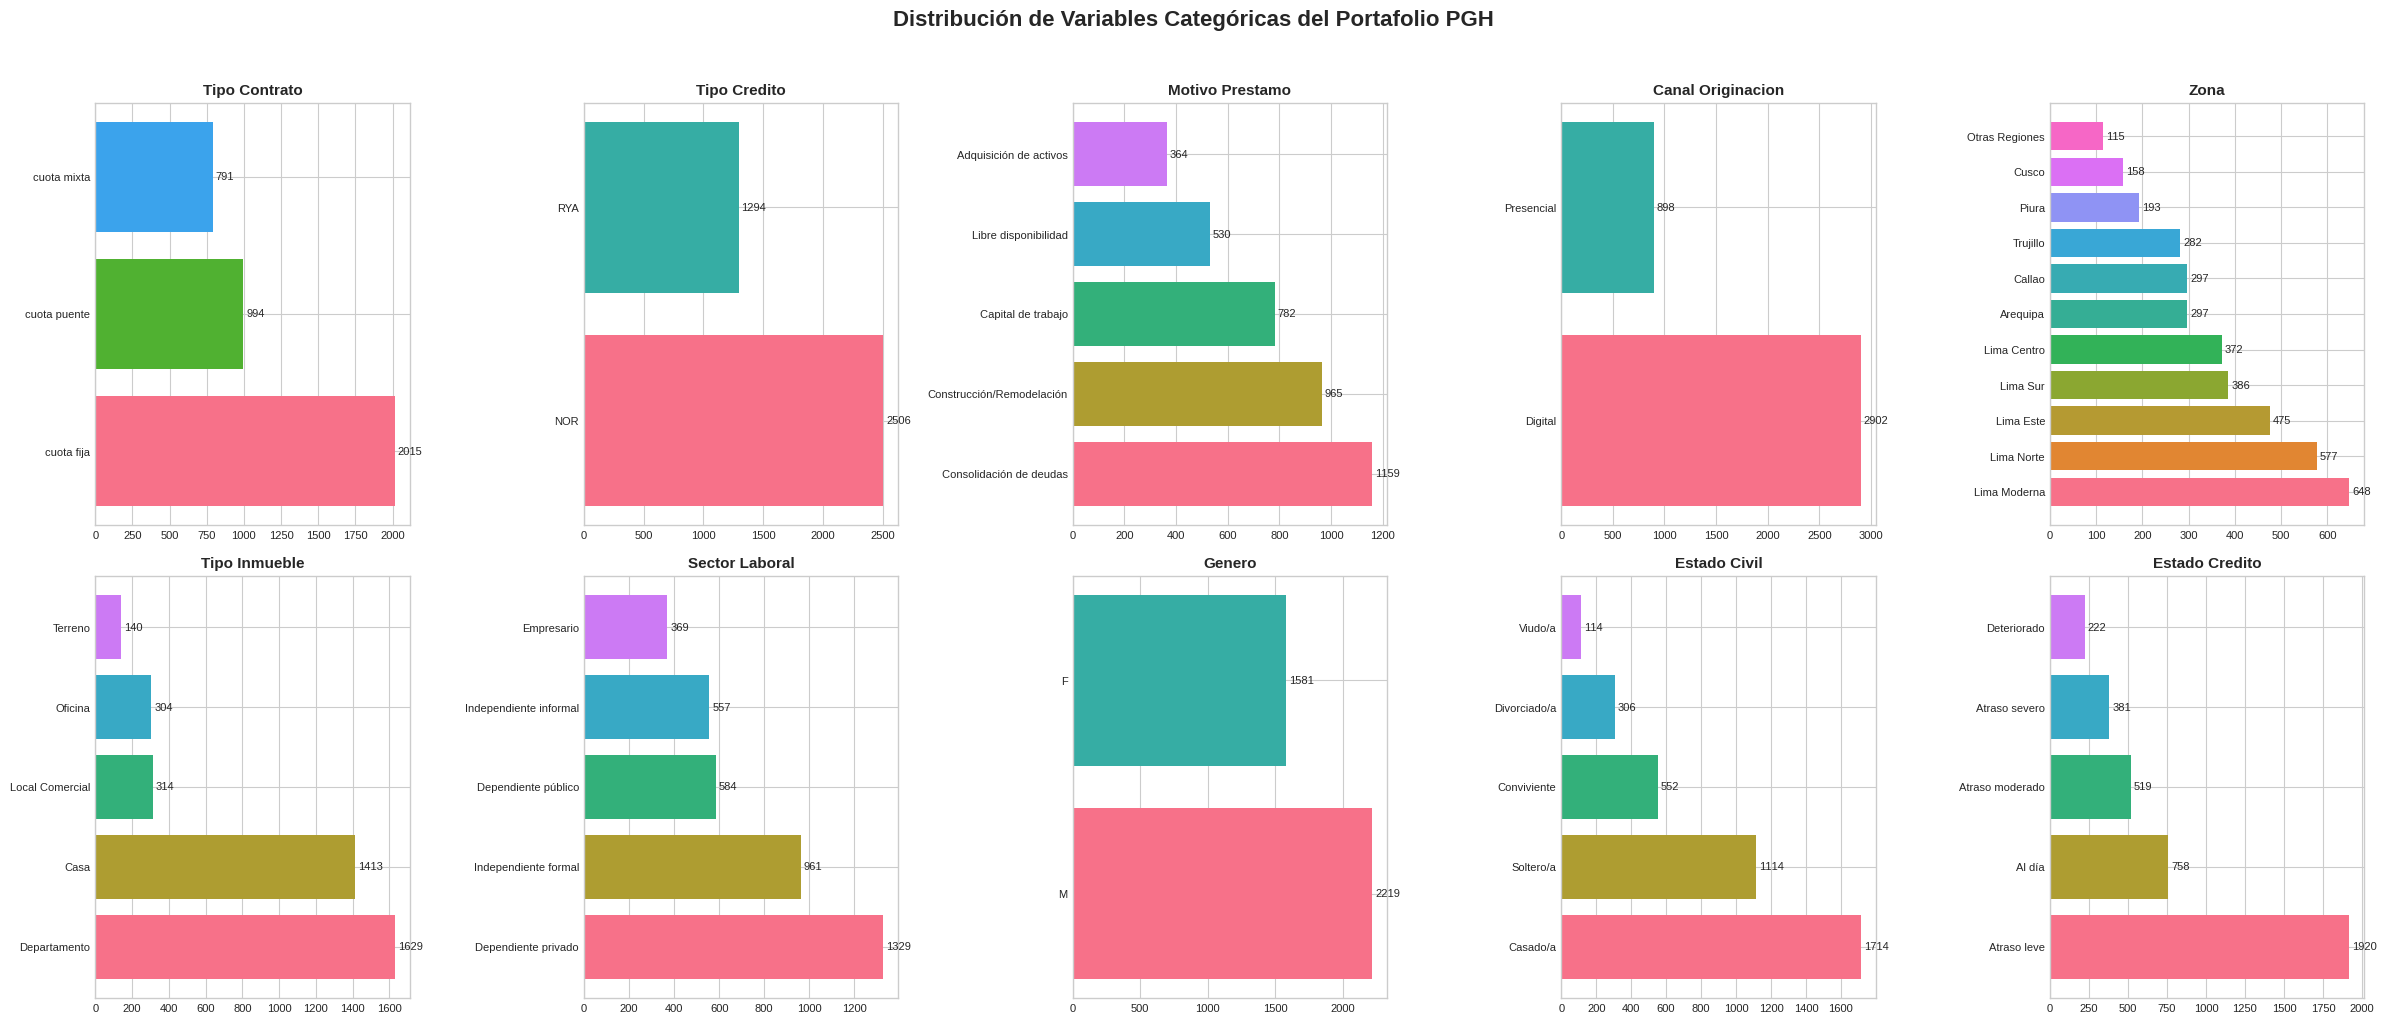

In [ ]:
# ============================================================
# 4.4 Distribución de variables categóricas
# ============================================================
cat_vars = ['tipo_contrato', 'tipo_credito', 'motivo_prestamo', 'canal_originacion',
            'zona', 'tipo_inmueble', 'sector_laboral', 'genero', 'estado_civil',
            'estado_credito']

fig, axes = plt.subplots(2, 5, figsize=(24, 10))
axes = axes.flatten()

for i, var in enumerate(cat_vars):
    counts = df[var].value_counts()
    axes[i].barh(counts.index, counts.values, color=sns.color_palette("husl", len(counts)))
    axes[i].set_title(var.replace('_', ' ').title(), fontsize=11, fontweight='bold')
    axes[i].tick_params(labelsize=8)
    for j, v in enumerate(counts.values):
        axes[i].text(v + max(counts.values)*0.01, j, str(v), va='center', fontsize=8)

plt.suptitle('Distribución de Variables Categóricas del Portafolio PGH', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


<a id="5"></a>
## 5. Ingeniería de features

Se crean variables derivadas que capturan señales de riesgo y patrones de comportamiento, enriqueciendo la capacidad predictiva de los modelos. Estas features se diseñan desde la perspectiva del negocio de PGH.


In [ ]:
# ============================================================
# 5.1 Features derivadas del comportamiento de pago (cosechas)
# ============================================================
# Identificar columnas de cosecha disponibles para cada contrato
cosecha_cols = [c for c in df.columns if c.startswith('atraso_m')]

# Convertir a numéricas (pueden tener vacíos en meses no vividos)
for col in cosecha_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# --- Métricas agregadas de comportamiento de cosechas ---

# Promedio de días de atraso en los primeros 12 meses (early performance)
early_cols = [f'atraso_m{str(i).zfill(3)}' for i in range(1, 13)]
early_cols = [c for c in early_cols if c in df.columns]
df['avg_atraso_12m'] = df[early_cols].mean(axis=1)

# Promedio de días de atraso en meses 13-24 (medium term)
mid_cols = [f'atraso_m{str(i).zfill(3)}' for i in range(13, 25)]
mid_cols = [c for c in mid_cols if c in df.columns]
df['avg_atraso_13_24m'] = df[mid_cols].mean(axis=1)

# Máximo atraso en primeros 6 meses (señal temprana de riesgo)
early6_cols = [f'atraso_m{str(i).zfill(3)}' for i in range(1, 7)]
early6_cols = [c for c in early6_cols if c in df.columns]
df['max_atraso_6m'] = df[early6_cols].max(axis=1)

# Volatilidad del atraso (desviación estándar) - mide inconsistencia de pago
df['std_atraso_12m'] = df[early_cols].std(axis=1)

# Tendencia de atraso: ¿mejora o empeora? (pendiente lineal primeros 12 meses)
def trend_slope(row):
    vals = row.dropna().values
    if len(vals) < 3:
        return 0.0
    x = np.arange(len(vals))
    slope = np.polyfit(x, vals, 1)[0]
    return slope

df['trend_atraso_12m'] = df[early_cols].apply(trend_slope, axis=1)

# Proporción de meses con atraso > 0 (frecuencia de incumplimiento)
df['pct_meses_con_atraso'] = df['meses_con_atraso'] / df['meses_transcurridos'].clip(lower=1)

# Flag: alguna vez tuvo atraso > 60 días
df['flag_alguna_vez_par60'] = (df['max_dias_atraso'] >= 60).astype(int)

print(f"✅ Features de cosecha creadas: avg_atraso_12m, avg_atraso_13_24m, max_atraso_6m,")
print(f"   std_atraso_12m, trend_atraso_12m, pct_meses_con_atraso, flag_alguna_vez_par60")


✅ Features de cosecha creadas: avg_atraso_12m, avg_atraso_13_24m, max_atraso_6m,
   std_atraso_12m, trend_atraso_12m, pct_meses_con_atraso, flag_alguna_vez_par60


In [ ]:
# ============================================================
# 5.2 Features derivadas del perfil y la operación
# ============================================================

# Ratio de capacidad de pago real
df['capacidad_pago'] = df['ingreso_neto_mensual'] - df['cuota_mensual_soles']

# Log del monto (normalización de escala)
df['log_loan_amount'] = np.log1p(df['loan_amount_soles'])

# Log del ingreso
df['log_ingreso'] = np.log1p(df['ingreso_neto_mensual'])

# Interacción: Score × LTV (riesgo combinado)
df['score_x_ltv'] = df['score_crediticio'] * df['ltv']

# Interacción: Score × Ratio deuda/ingreso
df['score_x_dti'] = df['score_crediticio'] * df['ratio_deuda_ingreso']

# Categoría de riesgo por score crediticio
df['cat_score'] = pd.cut(df['score_crediticio'],
                          bins=[0, 500, 600, 700, 800, 1000],
                          labels=['Muy Bajo', 'Bajo', 'Medio', 'Alto', 'Muy Alto'])

# Categoría de LTV
df['cat_ltv'] = pd.cut(df['ltv'],
                        bins=[0, 0.30, 0.50, 0.70, 1.0],
                        labels=['Conservador', 'Moderado', 'Agresivo', 'Muy Agresivo'])

# Monto relativo al valor del inmueble vs ingreso
df['ratio_prestamo_ingreso_anual'] = df['loan_amount_soles'] / (df['ingreso_neto_mensual'] * 12).clip(lower=1)

# Edad al momento de finalización del crédito
df['edad_fin_credito'] = df['edad'] + df['plazo_meses'] / 12

print(f"✅ Features de perfil y operación creadas")
print(f"   Total de columnas ahora: {len(df.columns)}")


✅ Features de perfil y operación creadas
   Total de columnas ahora: 176


<a id="6"></a>
## 6. Análisis Exploratorio de Datos (EDA)


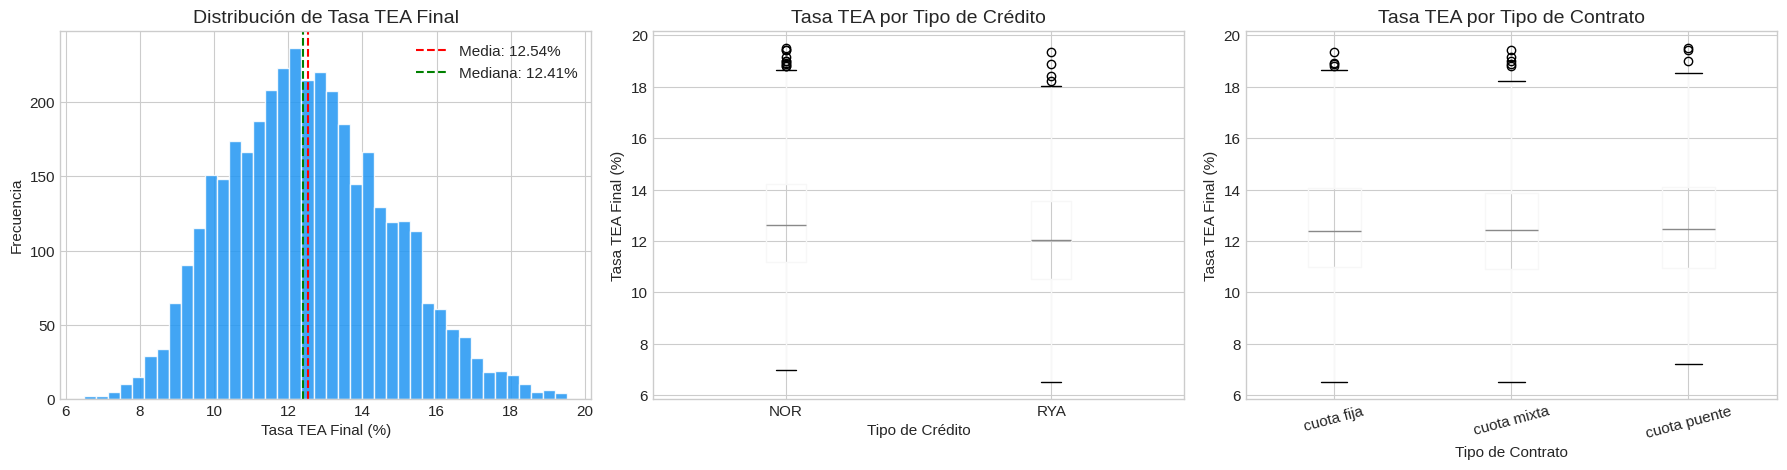

In [ ]:
# ============================================================
# 6.1 Distribución de la variable objetivo: tasa_tea_final
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histograma
axes[0].hist(df['tasa_tea_final'], bins=40, color='#2196F3', edgecolor='white', alpha=0.85)
axes[0].axvline(df['tasa_tea_final'].mean(), color='red', linestyle='--', label=f"Media: {df['tasa_tea_final'].mean():.2f}%")
axes[0].axvline(df['tasa_tea_final'].median(), color='green', linestyle='--', label=f"Mediana: {df['tasa_tea_final'].median():.2f}%")
axes[0].set_xlabel('Tasa TEA Final (%)')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución de Tasa TEA Final')
axes[0].legend()

# Box plot por tipo de crédito
df.boxplot(column='tasa_tea_final', by='tipo_credito', ax=axes[1])
axes[1].set_title('Tasa TEA por Tipo de Crédito')
axes[1].set_xlabel('Tipo de Crédito')
axes[1].set_ylabel('Tasa TEA Final (%)')
plt.sca(axes[1])
plt.xticks(rotation=0)

# Box plot por tipo de contrato
df.boxplot(column='tasa_tea_final', by='tipo_contrato', ax=axes[2])
axes[2].set_title('Tasa TEA por Tipo de Contrato')
axes[2].set_xlabel('Tipo de Contrato')
axes[2].set_ylabel('Tasa TEA Final (%)')
plt.sca(axes[2])
plt.xticks(rotation=15)

plt.suptitle('')
plt.tight_layout()
plt.show()


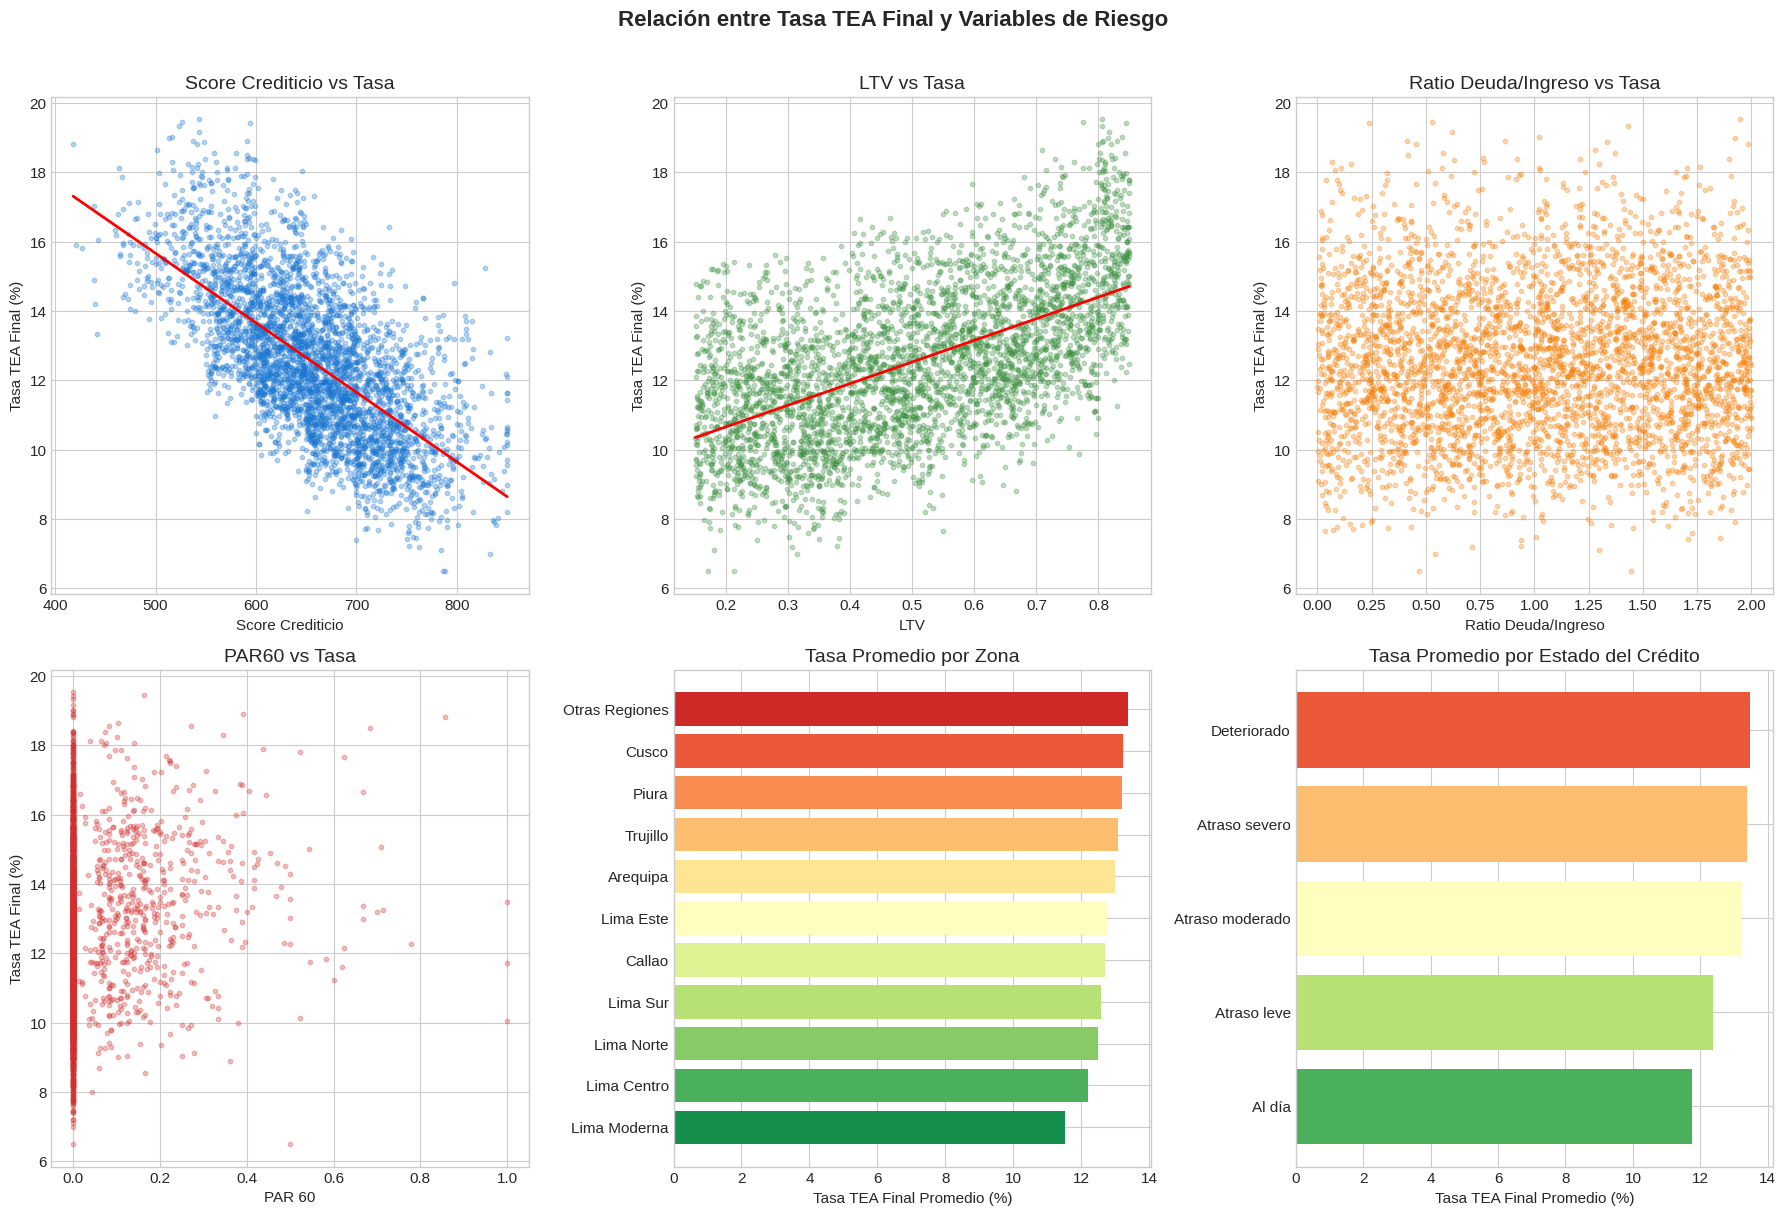

In [ ]:
# ============================================================
# 6.2 Tasa TEA vs variables de riesgo clave
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Score crediticio vs Tasa
axes[0,0].scatter(df['score_crediticio'], df['tasa_tea_final'], alpha=0.3, s=10, c='#1976D2')
z = np.polyfit(df['score_crediticio'], df['tasa_tea_final'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['score_crediticio'].min(), df['score_crediticio'].max(), 100)
axes[0,0].plot(x_line, p(x_line), 'r-', linewidth=2)
axes[0,0].set_xlabel('Score Crediticio')
axes[0,0].set_ylabel('Tasa TEA Final (%)')
axes[0,0].set_title('Score Crediticio vs Tasa')

# LTV vs Tasa
axes[0,1].scatter(df['ltv'], df['tasa_tea_final'], alpha=0.3, s=10, c='#388E3C')
z = np.polyfit(df['ltv'], df['tasa_tea_final'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['ltv'].min(), df['ltv'].max(), 100)
axes[0,1].plot(x_line, p(x_line), 'r-', linewidth=2)
axes[0,1].set_xlabel('LTV')
axes[0,1].set_ylabel('Tasa TEA Final (%)')
axes[0,1].set_title('LTV vs Tasa')

# Ratio Deuda/Ingreso vs Tasa
axes[0,2].scatter(df['ratio_deuda_ingreso'], df['tasa_tea_final'], alpha=0.3, s=10, c='#F57C00')
axes[0,2].set_xlabel('Ratio Deuda/Ingreso')
axes[0,2].set_ylabel('Tasa TEA Final (%)')
axes[0,2].set_title('Ratio Deuda/Ingreso vs Tasa')

# PAR60 vs Tasa
axes[1,0].scatter(df['par60'], df['tasa_tea_final'], alpha=0.3, s=10, c='#D32F2F')
axes[1,0].set_xlabel('PAR 60')
axes[1,0].set_ylabel('Tasa TEA Final (%)')
axes[1,0].set_title('PAR60 vs Tasa')

# Tasa por zona
tasa_zona = df.groupby('zona')['tasa_tea_final'].mean().sort_values()
axes[1,1].barh(tasa_zona.index, tasa_zona.values, color=sns.color_palette("RdYlGn_r", len(tasa_zona)))
axes[1,1].set_xlabel('Tasa TEA Final Promedio (%)')
axes[1,1].set_title('Tasa Promedio por Zona')

# Tasa por estado del crédito
tasa_estado = df.groupby('estado_credito')['tasa_tea_final'].mean().sort_values()
axes[1,2].barh(tasa_estado.index, tasa_estado.values, color=sns.color_palette("RdYlGn_r", len(tasa_estado)))
axes[1,2].set_xlabel('Tasa TEA Final Promedio (%)')
axes[1,2].set_title('Tasa Promedio por Estado del Crédito')

plt.suptitle('Relación entre Tasa TEA Final y Variables de Riesgo', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


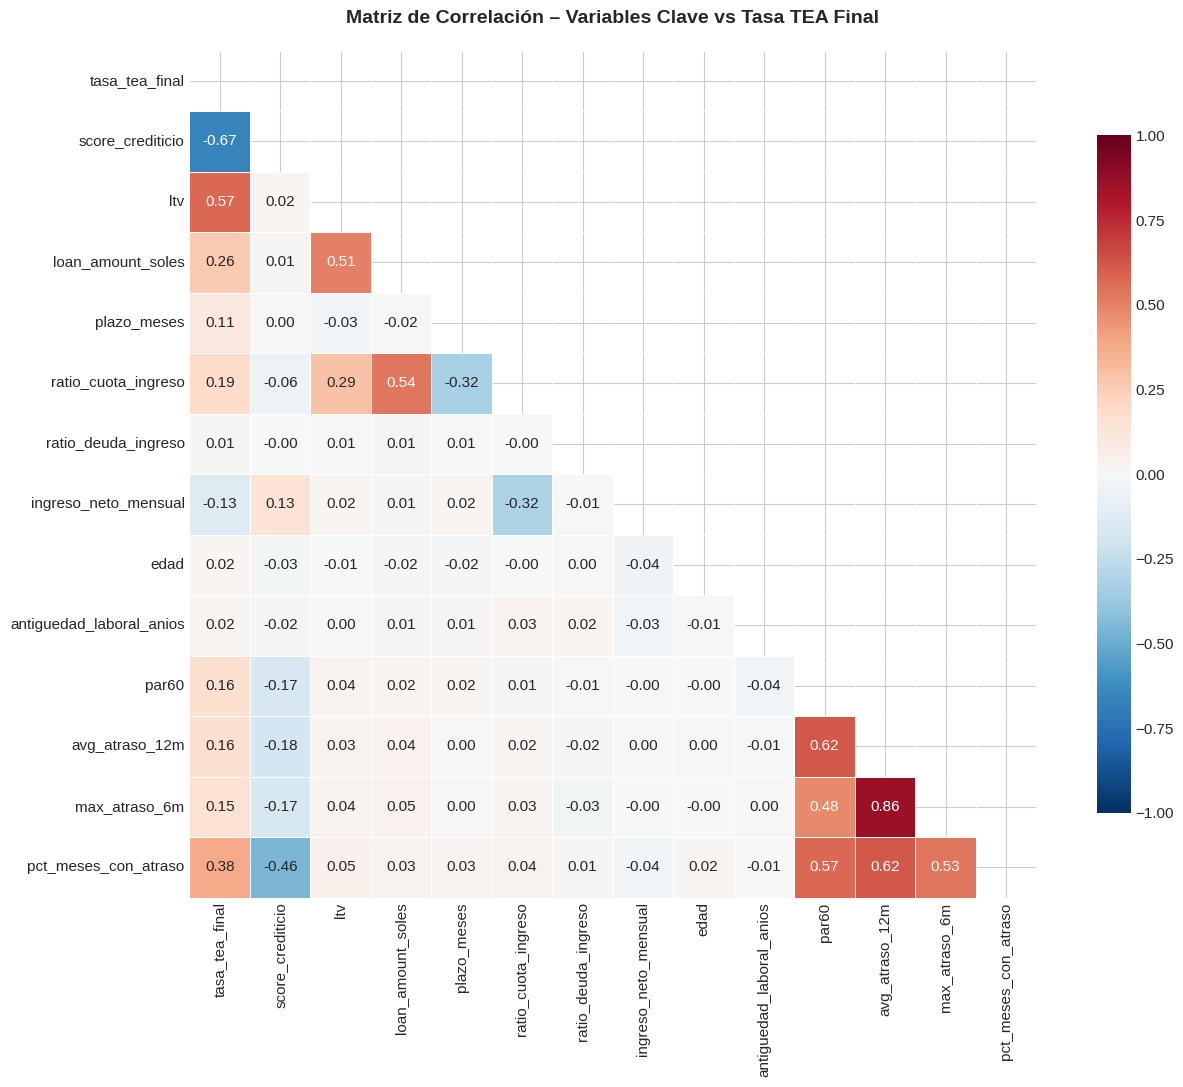


📊 Top correlaciones con tasa_tea_final:
--------------------------------------------------
  - score_crediticio                    -0.6671
  + ltv                                 +0.5730
  + pct_meses_con_atraso                +0.3826
  + loan_amount_soles                   +0.2615
  + ratio_cuota_ingreso                 +0.1933
  + avg_atraso_12m                      +0.1614
  + par60                               +0.1601
  + max_atraso_6m                       +0.1534
  - ingreso_neto_mensual                -0.1267
  + plazo_meses                         +0.1092
  + antiguedad_laboral_anios            +0.0235
  + edad                                +0.0229
  + ratio_deuda_ingreso                 +0.0125


In [ ]:
# ============================================================
# 6.3 Matriz de correlación de variables numéricas clave
# ============================================================
corr_vars = ['tasa_tea_final', 'score_crediticio', 'ltv', 'loan_amount_soles',
             'plazo_meses', 'ratio_cuota_ingreso', 'ratio_deuda_ingreso',
             'ingreso_neto_mensual', 'edad', 'antiguedad_laboral_anios',
             'par60', 'avg_atraso_12m', 'max_atraso_6m', 'pct_meses_con_atraso']

corr_matrix = df[corr_vars].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5,
            cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title('Matriz de Correlación – Variables Clave vs Tasa TEA Final',
             fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Top correlaciones con la variable objetivo
print("\n📊 Top correlaciones con tasa_tea_final:")
print("-" * 50)
target_corr = corr_matrix['tasa_tea_final'].drop('tasa_tea_final').abs().sort_values(ascending=False)
for var, val in target_corr.items():
    direction = "+" if corr_matrix.loc['tasa_tea_final', var] > 0 else "-"
    print(f"  {direction} {var:<35} {corr_matrix.loc['tasa_tea_final', var]:>+.4f}")


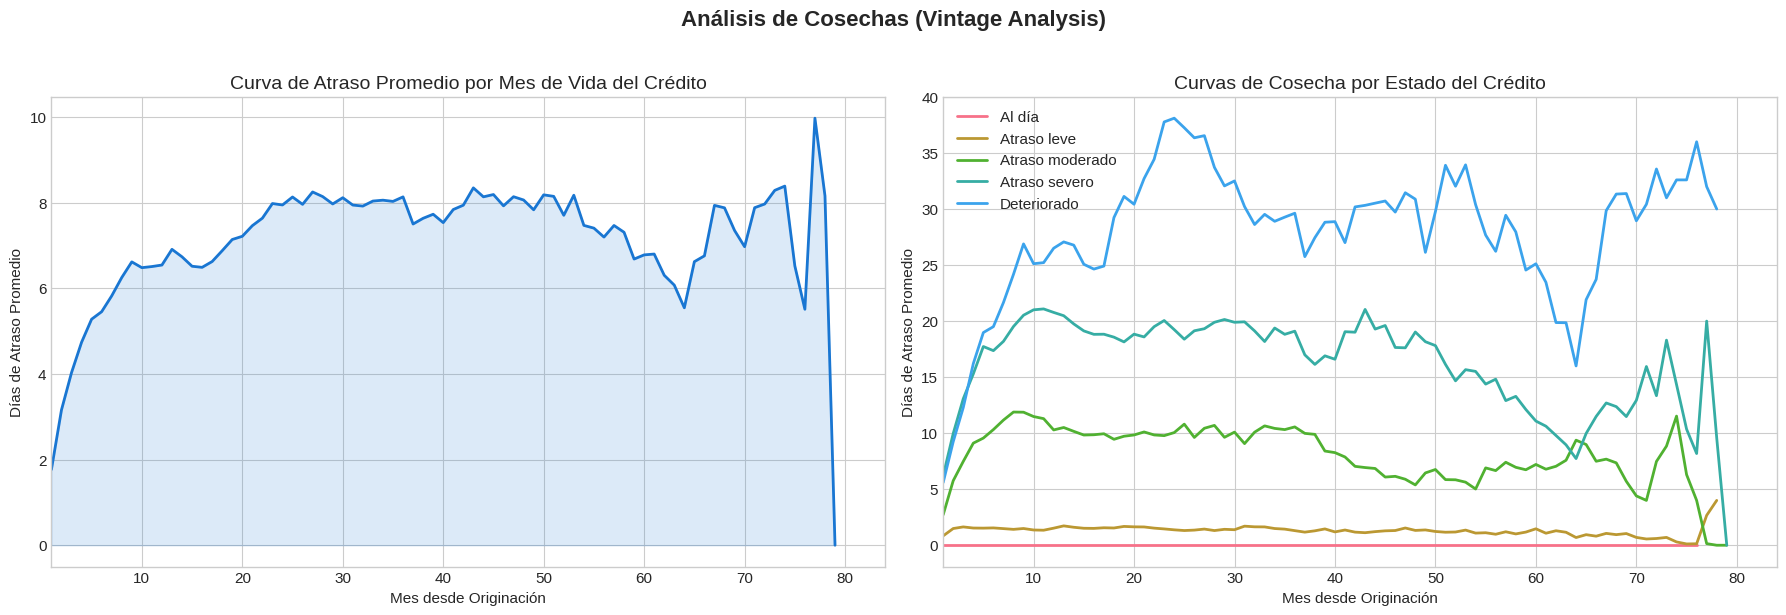

In [ ]:
# ============================================================
# 6.4 Análisis de cosechas (vintage analysis)
# ============================================================
# Curva de atraso promedio por mes desde la originación
cosecha_means = df[cosecha_cols].mean()
cosecha_means.index = range(1, len(cosecha_means) + 1)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Curva promedio general
axes[0].plot(cosecha_means.index, cosecha_means.values, color='#1976D2', linewidth=2)
axes[0].fill_between(cosecha_means.index, cosecha_means.values, alpha=0.15, color='#1976D2')
axes[0].set_xlabel('Mes desde Originación')
axes[0].set_ylabel('Días de Atraso Promedio')
axes[0].set_title('Curva de Atraso Promedio por Mes de Vida del Crédito')
axes[0].set_xlim(1, 84)

# Curva por estado de crédito
for estado in ['Al día', 'Atraso leve', 'Atraso moderado', 'Atraso severo', 'Deteriorado']:
    subset = df[df['estado_credito'] == estado]
    means = subset[cosecha_cols].mean()
    means.index = range(1, len(means) + 1)
    axes[1].plot(means.index[:84], means.values[:84], linewidth=2, label=estado)

axes[1].set_xlabel('Mes desde Originación')
axes[1].set_ylabel('Días de Atraso Promedio')
axes[1].set_title('Curvas de Cosecha por Estado del Crédito')
axes[1].legend(loc='upper left')
axes[1].set_xlim(1, 84)

plt.suptitle('Análisis de Cosechas (Vintage Analysis)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


<a id="7"></a>
## 7. Preparación de Datos para Modelado

Seleccionamos las features predictivas excluyendo variables que no estarían disponibles al momento de la originación o que representan fuga de información (data leakage). La variable objetivo es `tasa_tea_final`.


In [ ]:
# ============================================================
# 7.1 Selección de features
# ============================================================
# Features que SÍ estarían disponibles al momento de la decisión de tasa
# (incluimos métricas de comportamiento como proxy de riesgo aprendido del histórico)

features_numericas = [
    'loan_amount_soles', 'ltv', 'plazo_meses', 'valor_inmueble_soles',
    'edad', 'antiguedad_laboral_anios', 'ingreso_neto_mensual',
    'score_crediticio', 'numero_cuentas_activas', 'deuda_total_sistema_soles',
    'ratio_cuota_ingreso', 'ratio_deuda_ingreso', 'numero_dependientes',
    'vive_en_inmueble', 'tiene_garantia_adicional',
    # Features derivadas
    'log_loan_amount', 'log_ingreso', 'score_x_ltv', 'score_x_dti',
    'ratio_prestamo_ingreso_anual', 'edad_fin_credito',
    # Métricas de comportamiento (riesgo observado)
    'par60', 'max_dias_atraso', 'avg_atraso_12m', 'max_atraso_6m',
    'std_atraso_12m', 'trend_atraso_12m', 'pct_meses_con_atraso',
    'flag_alguna_vez_par60', 'prepago', 'refinanciado'
]

features_categoricas = [
    'tipo_contrato', 'tipo_credito', 'motivo_prestamo',
    'canal_originacion', 'zona', 'tipo_inmueble',
    'genero', 'estado_civil', 'sector_laboral'
]

target = 'tasa_tea_final'

print(f"📐 Features numéricas: {len(features_numericas)}")
print(f"📐 Features categóricas: {len(features_categoricas)}")
print(f"📐 Total features: {len(features_numericas) + len(features_categoricas)}")
print(f"🎯 Variable objetivo: {target}")


📐 Features numéricas: 31
📐 Features categóricas: 9
📐 Total features: 40
🎯 Variable objetivo: tasa_tea_final


In [ ]:
# ============================================================
# 7.2 Codificación de variables categóricas
# ============================================================
# Label Encoding para las categóricas (necesario para XGBoost y embeddings)
label_encoders = {}
df_model = df.copy()

for col in features_categoricas:
    le = LabelEncoder()
    df_model[col + '_encoded'] = le.fit_transform(df_model[col].astype(str))
    label_encoders[col] = le
    print(f"  {col}: {len(le.classes_)} categorías → {list(le.classes_)}")

# Para XGBoost usaremos One-Hot Encoding
# Para Deep Learning usaremos Embeddings (Label Encoded)


  tipo_contrato: 3 categorías → ['cuota fija', 'cuota mixta', 'cuota puente']
  tipo_credito: 2 categorías → ['NOR', 'RYA']
  motivo_prestamo: 5 categorías → ['Adquisición de activos', 'Capital de trabajo', 'Consolidación de deudas', 'Construcción/Remodelación', 'Libre disponibilidad']
  canal_originacion: 2 categorías → ['Digital', 'Presencial']
  zona: 11 categorías → ['Arequipa', 'Callao', 'Cusco', 'Lima Centro', 'Lima Este', 'Lima Moderna', 'Lima Norte', 'Lima Sur', 'Otras Regiones', 'Piura', 'Trujillo']
  tipo_inmueble: 5 categorías → ['Casa', 'Departamento', 'Local Comercial', 'Oficina', 'Terreno']
  genero: 2 categorías → ['F', 'M']
  estado_civil: 5 categorías → ['Casado/a', 'Conviviente', 'Divorciado/a', 'Soltero/a', 'Viudo/a']
  sector_laboral: 5 categorías → ['Dependiente privado', 'Dependiente público', 'Empresario', 'Independiente formal', 'Independiente informal']


In [ ]:
# ============================================================
# 7.3 Preparación de matrices X, y y split train/test
# ============================================================

# Rellenar NaN en features numéricas con 0 (atrasos no vividos = sin atraso)
df_model[features_numericas] = df_model[features_numericas].fillna(0)

# Reemplazar infinitos
df_model[features_numericas] = df_model[features_numericas].replace([np.inf, -np.inf], 0)

# --- Versión para XGBoost (One-Hot) ---
features_xgb = features_numericas + features_categoricas
X_xgb = df_model[features_xgb].copy()

# Convertir categóricas a dummies para XGBoost
X_xgb = pd.get_dummies(X_xgb, columns=features_categoricas, drop_first=True)
y = df_model[target].values

# Split estratificado (80/20)
X_train_xgb, X_test_xgb, y_train, y_test = train_test_split(
    X_xgb, y, test_size=0.20, random_state=SEED
)

print(f"📊 Train: {X_train_xgb.shape[0]:,} muestras")
print(f"📊 Test:  {X_test_xgb.shape[0]:,} muestras")
print(f"📊 Features XGBoost (con dummies): {X_train_xgb.shape[1]}")

# --- Versión para Deep Learning (escalada) ---
features_dl_num = features_numericas.copy()
features_dl_cat_enc = [col + '_encoded' for col in features_categoricas]

X_num = df_model[features_dl_num].values
X_cat = df_model[features_dl_cat_enc].values

# Escalar numéricas
scaler = StandardScaler()
X_num_train, X_num_test, _, _ = train_test_split(X_num, y, test_size=0.20, random_state=SEED)
X_cat_train, X_cat_test, _, _ = train_test_split(X_cat, y, test_size=0.20, random_state=SEED)

X_num_train_scaled = scaler.fit_transform(X_num_train)
X_num_test_scaled = scaler.transform(X_num_test)

print(f"📊 Features DL numéricas: {X_num_train_scaled.shape[1]}")
print(f"📊 Features DL categóricas: {X_cat_train.shape[1]}")
print(f"\n✅ Datos preparados para todos los modelos")


📊 Train: 3,040 muestras
📊 Test:  760 muestras
📊 Features XGBoost (con dummies): 62
📊 Features DL numéricas: 31
📊 Features DL categóricas: 9

✅ Datos preparados para todos los modelos


<a id="8"></a>
## 8. Modelo 1: Machine Learning – Gradient Boosting (XGBoost)

XGBoost es el baseline ideal para datos tabulares. Ofrece excelente rendimiento sin necesidad de escalar features y maneja bien las no-linealidades. Lo usamos como referencia contra la cual medir los modelos de Deep Learning.


In [ ]:
# ============================================================
# 8.1 Entrenamiento de XGBoost
# ============================================================
xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    min_child_weight=5,
    random_state=SEED,
    n_jobs=-1,
    early_stopping_rounds=30
)

xgb_model.fit(
    X_train_xgb, y_train,
    eval_set=[(X_test_xgb, y_test)],
    verbose=50
)

print(f"\n✅ XGBoost entrenado con {xgb_model.best_iteration} árboles (early stopping)")


[0]	validation_0-rmse:2.04083
[50]	validation_0-rmse:0.66381
[100]	validation_0-rmse:0.52824
[150]	validation_0-rmse:0.49262
[200]	validation_0-rmse:0.48242
[250]	validation_0-rmse:0.48071
[300]	validation_0-rmse:0.47867
[322]	validation_0-rmse:0.47887

✅ XGBoost entrenado con 292 árboles (early stopping)


RESULTADOS – XGBoost (Gradient Boosting)
  MAE:   0.3705 pp (puntos porcentuales de TEA)
  RMSE:  0.4786 pp
  R²:    0.9485
  MAPE:  3.10%


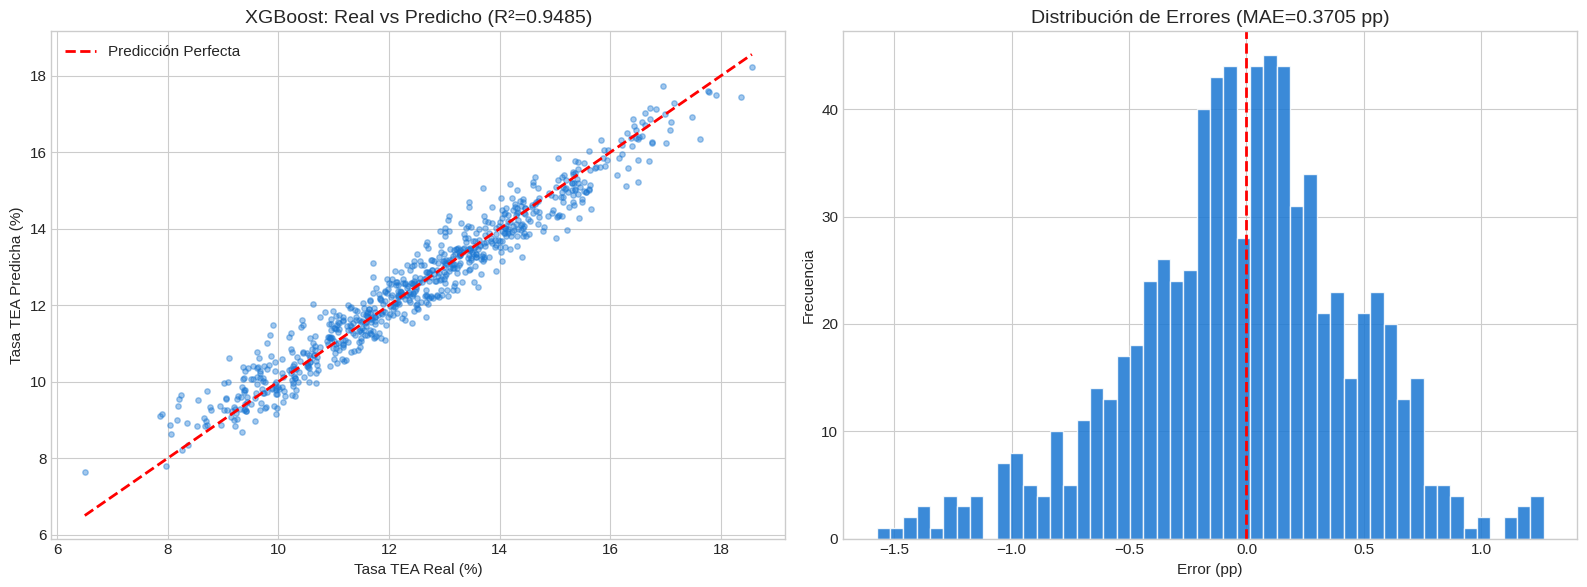

In [ ]:
# ============================================================
# 8.2 Evaluación de XGBoost
# ============================================================
y_pred_xgb = xgb_model.predict(X_test_xgb)

mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)
mape_xgb = np.mean(np.abs((y_test - y_pred_xgb) / y_test)) * 100

print("=" * 55)
print("RESULTADOS – XGBoost (Gradient Boosting)")
print("=" * 55)
print(f"  MAE:   {mae_xgb:.4f} pp (puntos porcentuales de TEA)")
print(f"  RMSE:  {rmse_xgb:.4f} pp")
print(f"  R²:    {r2_xgb:.4f}")
print(f"  MAPE:  {mape_xgb:.2f}%")
print("=" * 55)

# Gráfico Real vs Predicho
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(y_test, y_pred_xgb, alpha=0.4, s=15, c='#1976D2')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2, label='Predicción Perfecta')
axes[0].set_xlabel('Tasa TEA Real (%)')
axes[0].set_ylabel('Tasa TEA Predicha (%)')
axes[0].set_title(f'XGBoost: Real vs Predicho (R²={r2_xgb:.4f})')
axes[0].legend()

# Distribución de errores
errores_xgb = y_test - y_pred_xgb
axes[1].hist(errores_xgb, bins=50, color='#1976D2', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Error (pp)')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title(f'Distribución de Errores (MAE={mae_xgb:.4f} pp)')

plt.tight_layout()
plt.show()


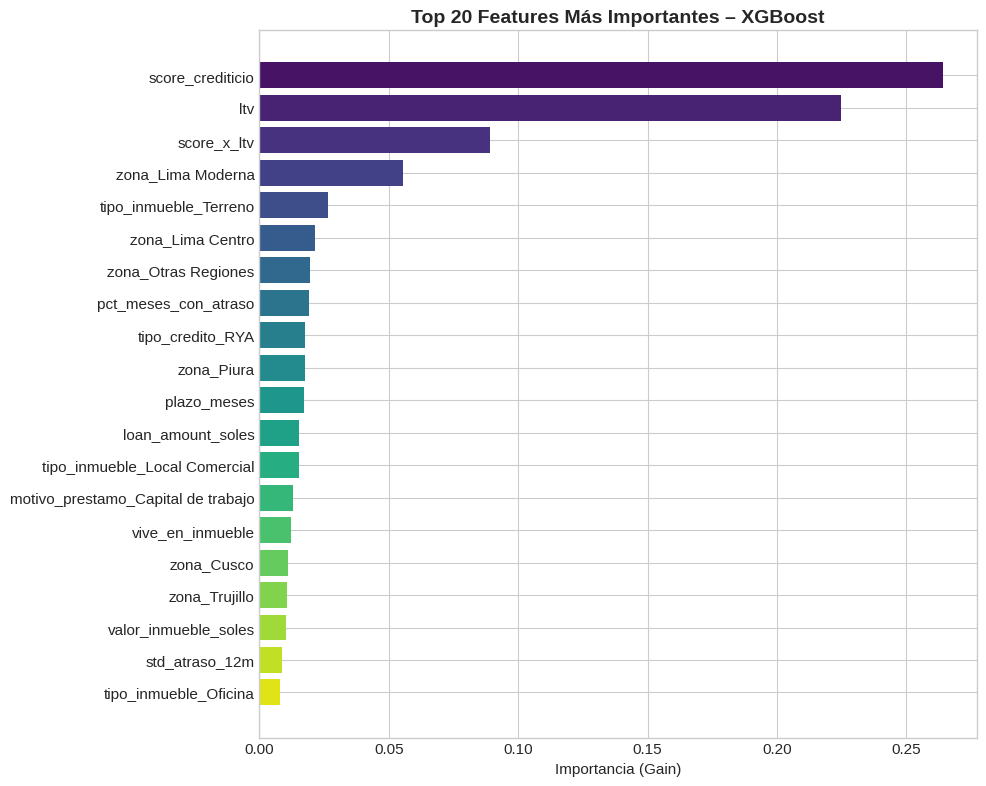

In [ ]:
# ============================================================
# 8.3 Importancia de Features – XGBoost
# ============================================================
importance = xgb_model.feature_importances_
feat_importance = pd.DataFrame({
    'feature': X_train_xgb.columns,
    'importance': importance
}).sort_values('importance', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(feat_importance['feature'][::-1], feat_importance['importance'][::-1],
        color=sns.color_palette("viridis", 20)[::-1])
ax.set_xlabel('Importancia (Gain)')
ax.set_title('Top 20 Features Más Importantes – XGBoost', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


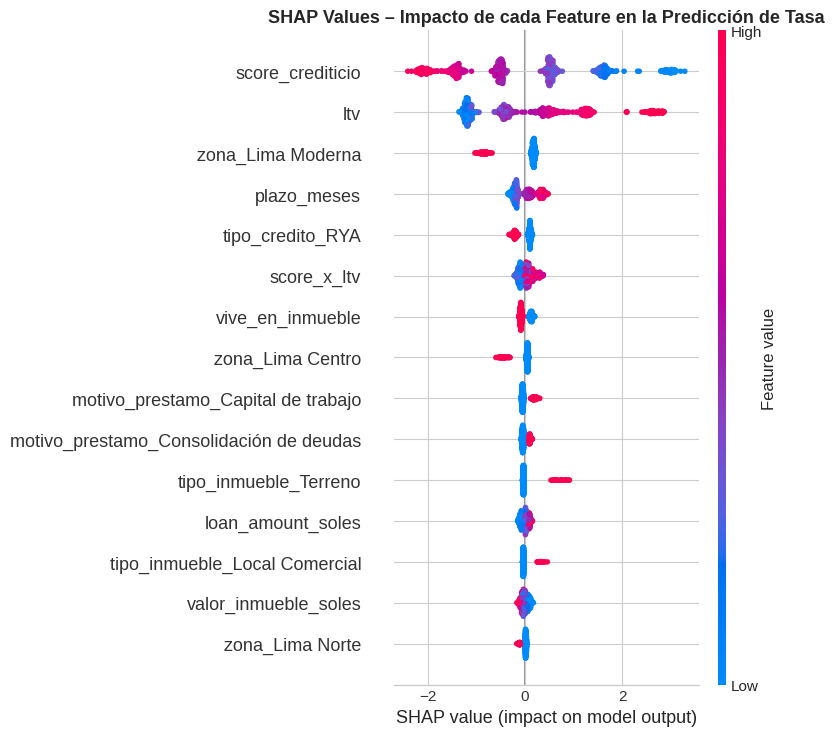

In [ ]:
# ============================================================
# 8.4 SHAP – Interpretabilidad del modelo XGBoost
# ============================================================
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_xgb)

fig, ax = plt.subplots(figsize=(12, 8))
shap.summary_plot(shap_values, X_test_xgb, max_display=15, show=False)
plt.title('SHAP Values – Impacto de cada Feature en la Predicción de Tasa', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


<a id="9"></a>
## 9. Modelo 2: Deep Learning – Red Neuronal Profunda (DNN)

Implementamos una red neuronal densa (fully connected) con regularización (Dropout, L2) y Batch Normalization. Usamos las features numéricas escaladas junto con las categóricas codificadas con One-Hot.


In [ ]:
# ============================================================
# 9.1 Preparación de datos para DNN simple
# ============================================================
# Concatenamos numéricas escaladas + categóricas one-hot para la versión simple
X_cat_onehot_train = pd.get_dummies(
    pd.DataFrame(X_cat_train, columns=features_dl_cat_enc)
).values
X_cat_onehot_test = pd.get_dummies(
    pd.DataFrame(X_cat_test, columns=features_dl_cat_enc)
).values

# Asegurar mismo número de columnas
from sklearn.preprocessing import OneHotEncoder as OHE
ohe = OHE(sparse_output=False, handle_unknown='ignore')
X_cat_ohe_train = ohe.fit_transform(X_cat_train)
X_cat_ohe_test = ohe.transform(X_cat_test)

X_dl_train = np.hstack([X_num_train_scaled, X_cat_ohe_train])
X_dl_test = np.hstack([X_num_test_scaled, X_cat_ohe_test])

print(f"📊 Input DNN simple: {X_dl_train.shape[1]} features")
print(f"   ({X_num_train_scaled.shape[1]} numéricas + {X_cat_ohe_train.shape[1]} categóricas one-hot)")


📊 Input DNN simple: 71 features
   (31 numéricas + 40 categóricas one-hot)


In [ ]:
# ============================================================
# 9.2 Arquitectura de la Red Neuronal Profunda
# ============================================================
def build_dnn(input_dim, name='DNN_PGH'):
    model = keras.Sequential(name=name)

    # Capa de entrada
    model.add(layers.Dense(256, input_dim=input_dim,
                           kernel_regularizer=regularizers.l2(1e-4)))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.Dropout(0.3))

    # Capa oculta 2
    model.add(layers.Dense(128, kernel_regularizer=regularizers.l2(1e-4)))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.Dropout(0.25))

    # Capa oculta 3
    model.add(layers.Dense(64, kernel_regularizer=regularizers.l2(1e-4)))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.Dropout(0.2))

    # Capa oculta 4
    model.add(layers.Dense(32))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))

    # Capa de salida (regresión)
    model.add(layers.Dense(1, activation='linear'))

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='mse',
        metrics=['mae']
    )
    return model

dnn_model = build_dnn(X_dl_train.shape[1])
dnn_model.summary()


Model: "DNN_PGH"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 256)            │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 63,617 (248.50 KB)

 Trainable params: 62,657 (244.75 KB)

 Non-trainable params: 960 (3.75 KB)

In [ ]:
# ============================================================
# 9.3 Entrenamiento de la DNN
# ============================================================
early_stop = callbacks.EarlyStopping(
    monitor='val_loss', patience=20, restore_best_weights=True, verbose=1
)
reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=8, min_lr=1e-6, verbose=1
)

history_dnn = dnn_model.fit(
    X_dl_train, y_train,
    validation_split=0.15,
    epochs=200,
    batch_size=64,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

print("\n✅ DNN entrenada correctamente")


Epoch 1/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - loss: 157.4216 - mae: 12.3685 - val_loss: 152.1027 - val_mae: 12.1763 - learning_rate: 0.0010
Epoch 2/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 136.0481 - mae: 11.5250 - val_loss: 143.2132 - val_mae: 11.8459 - learning_rate: 0.0010
Epoch 3/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 115.6304 - mae: 10.6306 - val_loss: 130.3599 - val_mae: 11.3276 - learning_rate: 0.0010
Epoch 4/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 96.5170 - mae: 9.7058 - val_loss: 117.7654 - val_mae: 10.7629 - learning_rate: 0.0010
Epoch 5/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 79.0465 - mae: 8.7535 - val_loss: 98.4858 - val_mae: 9.8434 - learning_rate: 0.0010
Epoch 6/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 62.2102 - mae: 7.7390 - val_loss: 79.1597 - val_mae: 8.8050 - learning_rate: 0.0010
Epoch 7/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 47.6974 - mae: 6.7207 - val_loss: 60.4647 - val_mae: 7.6575 - learni

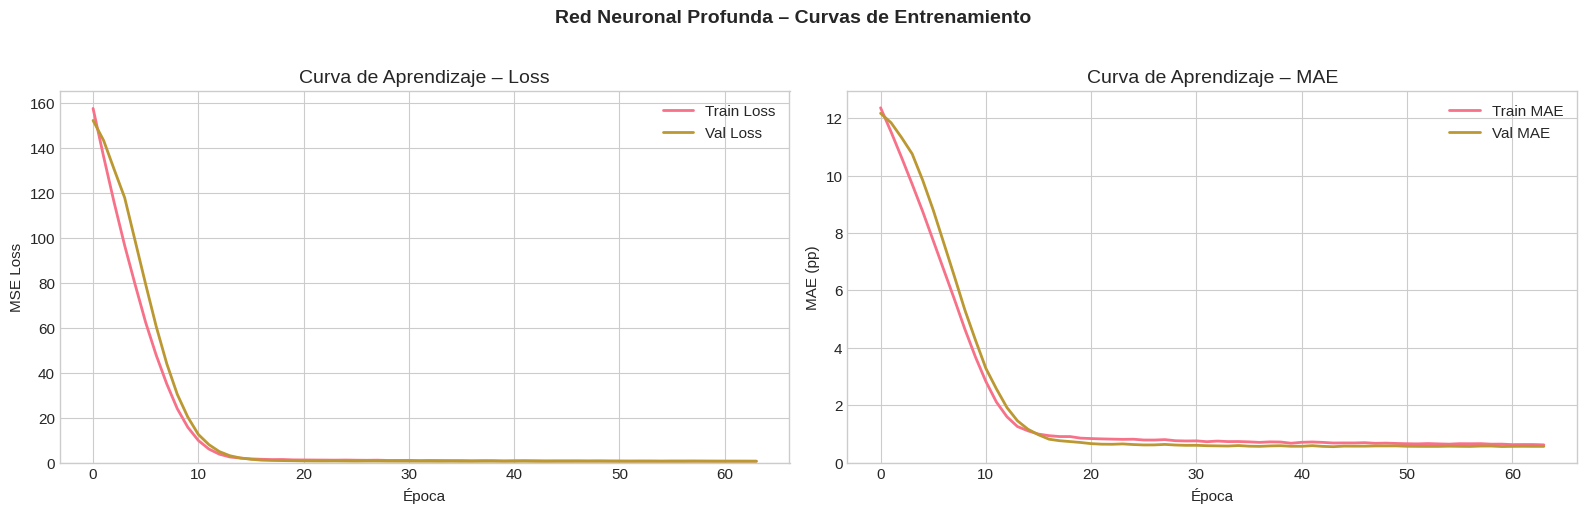

In [ ]:
# ============================================================
# 9.4 Curvas de aprendizaje DNN
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Loss
axes[0].plot(history_dnn.history['loss'], label='Train Loss', linewidth=2)
axes[0].plot(history_dnn.history['val_loss'], label='Val Loss', linewidth=2)
axes[0].set_xlabel('Época')
axes[0].set_ylabel('MSE Loss')
axes[0].set_title('Curva de Aprendizaje – Loss')
axes[0].legend()
axes[0].set_ylim(bottom=0)

# MAE
axes[1].plot(history_dnn.history['mae'], label='Train MAE', linewidth=2)
axes[1].plot(history_dnn.history['val_mae'], label='Val MAE', linewidth=2)
axes[1].set_xlabel('Época')
axes[1].set_ylabel('MAE (pp)')
axes[1].set_title('Curva de Aprendizaje – MAE')
axes[1].legend()
axes[1].set_ylim(bottom=0)

plt.suptitle('Red Neuronal Profunda – Curvas de Entrenamiento', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
RESULTADOS – Red Neuronal Profunda (DNN)
  MAE:   0.5558 pp
  RMSE:  0.6978 pp
  R²:    0.8905
  MAPE:  4.55%


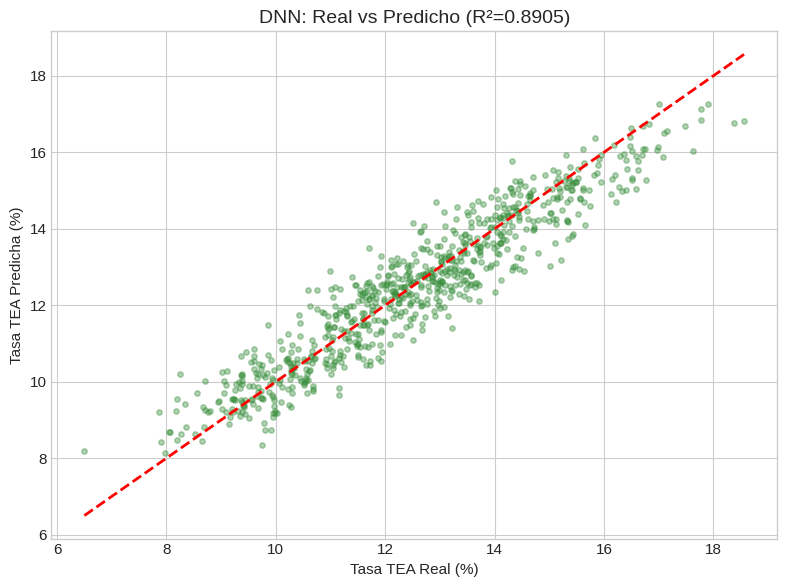

In [ ]:
# ============================================================
# 9.5 Evaluación de la DNN
# ============================================================
y_pred_dnn = dnn_model.predict(X_dl_test).flatten()

# Safety check: reemplazar NaN en predicciones si los hubiera
y_pred_dnn = np.nan_to_num(y_pred_dnn, nan=df['tasa_tea_final'].mean())

mae_dnn = mean_absolute_error(y_test, y_pred_dnn)
rmse_dnn = np.sqrt(mean_squared_error(y_test, y_pred_dnn))
r2_dnn = r2_score(y_test, y_pred_dnn)
mape_dnn = np.mean(np.abs((y_test - y_pred_dnn) / y_test)) * 100

print("=" * 55)
print("RESULTADOS – Red Neuronal Profunda (DNN)")
print("=" * 55)
print(f"  MAE:   {mae_dnn:.4f} pp")
print(f"  RMSE:  {rmse_dnn:.4f} pp")
print(f"  R²:    {r2_dnn:.4f}")
print(f"  MAPE:  {mape_dnn:.2f}%")
print("=" * 55)

# Real vs Predicho
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(y_test, y_pred_dnn, alpha=0.4, s=15, c='#388E3C')
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
ax.set_xlabel('Tasa TEA Real (%)')
ax.set_ylabel('Tasa TEA Predicha (%)')
ax.set_title(f'DNN: Real vs Predicho (R²={r2_dnn:.4f})')
plt.tight_layout()
plt.show()


<a id="10"></a>
## 10. Modelo 3: Deep Learning Avanzado – Red con Embeddings Categóricos

Los **embeddings** permiten que la red neuronal aprenda representaciones densas de las variables categóricas, capturando relaciones semánticas (por ejemplo, que "Lima Norte" y "Lima Este" son más similares entre sí que con "Cusco"). Esta es una ventaja significativa del Deep Learning sobre el One-Hot Encoding tradicional.


In [ ]:
# ============================================================
# 10.1 Arquitectura con Embeddings Categóricos (Functional API)
# ============================================================
# Definir dimensiones de embedding para cada variable categórica
# Regla: min(50, n_categorías // 2 + 1)
embedding_dims = {}
for col in features_categoricas:
    n_cats = len(label_encoders[col].classes_)
    emb_dim = min(50, max(2, n_cats // 2 + 1))
    embedding_dims[col] = (n_cats, emb_dim)
    print(f"  {col}: {n_cats} categorías → embedding dim {emb_dim}")

def build_embedding_model():
    # --- Inputs numéricos ---
    num_input = Input(shape=(len(features_dl_num),), name='numerical_input')

    # --- Inputs y Embeddings categóricos ---
    cat_inputs = []
    cat_embeddings = []

    for i, col in enumerate(features_categoricas):
        n_cats, emb_dim = embedding_dims[col]
        inp = Input(shape=(1,), name=f'cat_{col}')
        emb = layers.Embedding(n_cats, emb_dim, name=f'emb_{col}')(inp)
        emb = layers.Flatten()(emb)
        cat_inputs.append(inp)
        cat_embeddings.append(emb)

    # --- Concatenar todo ---
    if cat_embeddings:
        cat_concat = layers.Concatenate()(cat_embeddings)
        x = layers.Concatenate()([num_input, cat_concat])
    else:
        x = num_input

    # --- Red profunda ---
    x = layers.Dense(256, kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Dense(128, kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.25)(x)

    x = layers.Dense(64, kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.2)(x)

    x = layers.Dense(32)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    output = layers.Dense(1, activation='linear', name='tasa_output')(x)

    model = Model(inputs=[num_input] + cat_inputs, outputs=output, name='DNN_Embeddings_PGH')

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='mse',
        metrics=['mae']
    )
    return model

emb_model = build_embedding_model()
emb_model.summary()


  tipo_contrato: 3 categorías → embedding dim 2
  tipo_credito: 2 categorías → embedding dim 2
  motivo_prestamo: 5 categorías → embedding dim 3
  canal_originacion: 2 categorías → embedding dim 2
  zona: 11 categorías → embedding dim 6
  tipo_inmueble: 5 categorías → embedding dim 3
  genero: 2 categorías → embedding dim 2
  estado_civil: 5 categorías → embedding dim 3
  sector_laboral: 5 categorías → embedding dim 3


Model: "DNN_Embeddings_PGH"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ cat_tipo_contrato   │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cat_tipo_credito    │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cat_motivo_prestamo │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cat_canal_originac… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cat_zona            │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cat_tipo_inmueble   │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cat_genero          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cat_estado_civil    │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cat_sector_laboral  │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_tipo_contrato   │ (None, 1, 2)      │          6 │ cat_tipo_contrat… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_tipo_credito    │ (None, 1, 2)      │          4 │ cat_tipo_credito… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_motivo_prestamo │ (None, 1, 3)      │         15 │ cat_motivo_prest… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_canal_originac… │ (None, 1, 2)      │          4 │ cat_canal_origin… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_zona            │ (None, 1, 6)      │         66 │ cat_zona[0][0]    │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_tipo_inmueble   │ (None, 1, 3)      │         15 │ cat_tipo_inmuebl… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_genero          │ (None, 1, 2)      │          4 │ cat_genero[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_estado_civil    │ (None, 1, 3)      │         15 │ cat_estado_civil

 Total params: 60,177 (235.07 KB)

 Trainable params: 59,217 (231.32 KB)

 Non-trainable params: 960 (3.75 KB)

In [ ]:
# ============================================================
# 10.2 Preparar inputs para el modelo con embeddings
# ============================================================
def prepare_embedding_inputs(X_num, X_cat):
    inputs = [X_num]
    for i in range(X_cat.shape[1]):
        inputs.append(X_cat[:, i].reshape(-1, 1))
    return inputs

train_inputs = prepare_embedding_inputs(X_num_train_scaled, X_cat_train)
test_inputs = prepare_embedding_inputs(X_num_test_scaled, X_cat_test)

print(f"✅ Inputs preparados: {len(train_inputs)} tensores")
print(f"   - 1 tensor numérico: shape {train_inputs[0].shape}")
print(f"   - {len(train_inputs)-1} tensores categóricos (1 por variable)")


✅ Inputs preparados: 10 tensores
   - 1 tensor numérico: shape (3040, 31)
   - 9 tensores categóricos (1 por variable)


In [ ]:
# ============================================================
# 10.3 Entrenamiento del modelo con Embeddings
# ============================================================
early_stop_emb = callbacks.EarlyStopping(
    monitor='val_loss', patience=20, restore_best_weights=True, verbose=1
)
reduce_lr_emb = callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=8, min_lr=1e-6, verbose=1
)

history_emb = emb_model.fit(
    train_inputs, y_train,
    validation_split=0.15,
    epochs=200,
    batch_size=64,
    callbacks=[early_stop_emb, reduce_lr_emb],
    verbose=1
)

print("\n✅ Modelo con Embeddings entrenado correctamente")


Epoch 1/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 7s 38ms/step - loss: 127.9266 - mae: 11.1341 - val_loss: 148.3870 - val_mae: 12.0380 - learning_rate: 0.0010
Epoch 2/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 107.7371 - mae: 10.2534 - val_loss: 129.5036 - val_mae: 11.2817 - learning_rate: 0.0010
Epoch 3/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 88.9166 - mae: 9.3094 - val_loss: 109.5483 - val_mae: 10.3907 - learning_rate: 0.0010
Epoch 4/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 71.4875 - mae: 8.3140 - val_loss: 88.6393 - val_mae: 9.3479 - learning_rate: 0.0010
Epoch 5/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 54.6181 - mae: 7.2435 - val_loss: 68.6254 - val_mae: 8.2163 - learning_rate: 0.0010
Epoch 6/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 40.0512 - mae: 6.1481 - val_loss: 49.9423 - val_mae: 6.9821 - learning_rate: 0.0010
Epoch 7/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 27.6487 - mae: 5.0493 - val_loss: 36.0586 - val_mae: 5.9022 - lear

24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step
RESULTADOS – DNN con Embeddings Categóricos
  MAE:   0.5320 pp
  RMSE:  0.6621 pp
  R²:    0.9014
  MAPE:  4.36%


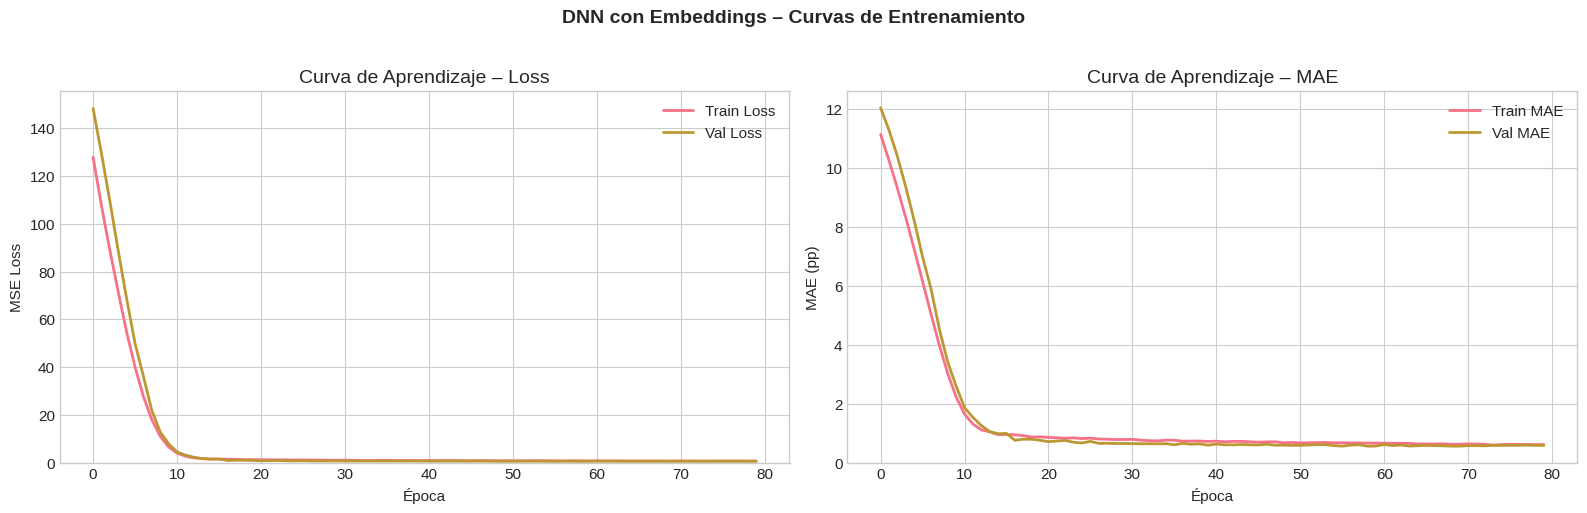

In [ ]:
# ============================================================
# 10.4 Evaluación del modelo con Embeddings
# ============================================================
y_pred_emb = emb_model.predict(test_inputs).flatten()

mae_emb = mean_absolute_error(y_test, y_pred_emb)
rmse_emb = np.sqrt(mean_squared_error(y_test, y_pred_emb))
r2_emb = r2_score(y_test, y_pred_emb)
mape_emb = np.mean(np.abs((y_test - y_pred_emb) / y_test)) * 100

print("=" * 55)
print("RESULTADOS – DNN con Embeddings Categóricos")
print("=" * 55)
print(f"  MAE:   {mae_emb:.4f} pp")
print(f"  RMSE:  {rmse_emb:.4f} pp")
print(f"  R²:    {r2_emb:.4f}")
print(f"  MAPE:  {mape_emb:.2f}%")
print("=" * 55)

# Curvas de aprendizaje
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].plot(history_emb.history['loss'], label='Train Loss', linewidth=2)
axes[0].plot(history_emb.history['val_loss'], label='Val Loss', linewidth=2)
axes[0].set_xlabel('Época'); axes[0].set_ylabel('MSE Loss')
axes[0].set_title('Curva de Aprendizaje – Loss'); axes[0].legend(); axes[0].set_ylim(bottom=0)

axes[1].plot(history_emb.history['mae'], label='Train MAE', linewidth=2)
axes[1].plot(history_emb.history['val_mae'], label='Val MAE', linewidth=2)
axes[1].set_xlabel('Época'); axes[1].set_ylabel('MAE (pp)')
axes[1].set_title('Curva de Aprendizaje – MAE'); axes[1].legend(); axes[1].set_ylim(bottom=0)

plt.suptitle('DNN con Embeddings – Curvas de Entrenamiento', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


<a id="11"></a>
## 11. Comparación de modelos y selección


In [ ]:
# ============================================================
# 11.1 Tabla comparativa de resultados
# ============================================================
resultados = pd.DataFrame({
    'Modelo': ['XGBoost (Baseline ML)', 'DNN Simple (DL)', 'DNN + Embeddings (DL Avanzado)'],
    'MAE (pp)': [mae_xgb, mae_dnn, mae_emb],
    'RMSE (pp)': [rmse_xgb, rmse_dnn, rmse_emb],
    'R²': [r2_xgb, r2_dnn, r2_emb],
    'MAPE (%)': [mape_xgb, mape_dnn, mape_emb]
})

print("=" * 80)
print("COMPARACIÓN DE MODELOS – PREDICCIÓN DE TASA TEA FINAL")
print("=" * 80)
display(resultados.round(4))

# Identificar mejor modelo
mejor_idx = resultados['MAE (pp)'].idxmin()
print(f"\n🏆 Mejor modelo por MAE: {resultados.loc[mejor_idx, 'Modelo']}")
print(f"   MAE = {resultados.loc[mejor_idx, 'MAE (pp)']:.4f} pp de TEA")
print(f"   R²  = {resultados.loc[mejor_idx, 'R²']:.4f}")


COMPARACIÓN DE MODELOS – PREDICCIÓN DE TASA TEA FINAL


,Modelo,MAE (pp),RMSE (pp),R²,MAPE (%)
0,XGBoost (Baseline ML),0.3705,0.4786,0.9485,3.0984
1,DNN Simple (DL),0.5558,0.6978,0.8905,4.5495
2,DNN + Embeddings (DL Avanzado),0.5320,0.6621,0.9014,4.3617



🏆 Mejor modelo por MAE: XGBoost (Baseline ML)
   MAE = 0.3705 pp de TEA
   R²  = 0.9485


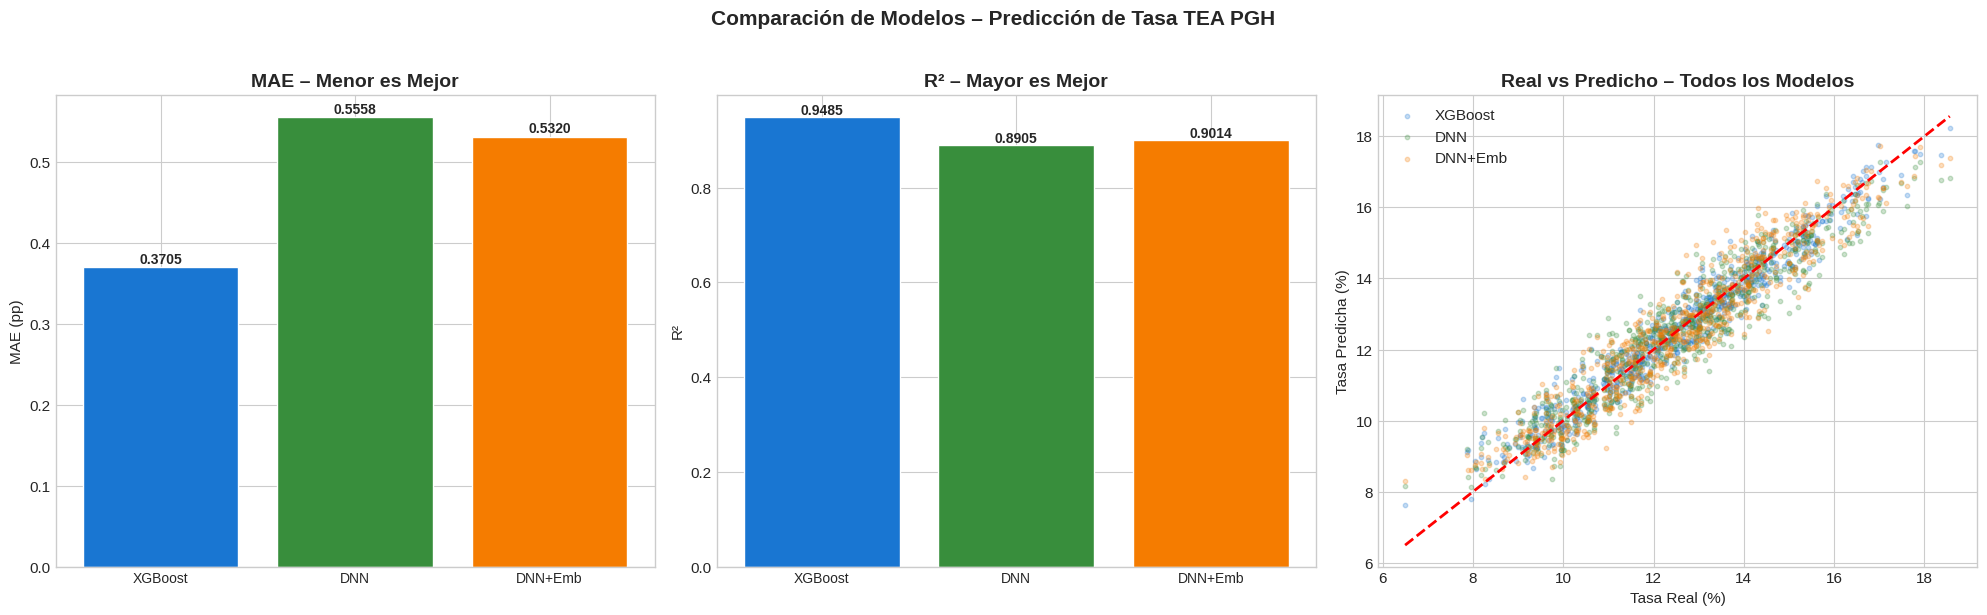

In [ ]:
# ============================================================
# 11.2 Visualización comparativa
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

modelos = resultados['Modelo'].values
colores = ['#1976D2', '#388E3C', '#F57C00']

# MAE
bars = axes[0].bar(range(len(modelos)), resultados['MAE (pp)'], color=colores, edgecolor='white')
axes[0].set_xticks(range(len(modelos)))
axes[0].set_xticklabels(['XGBoost', 'DNN', 'DNN+Emb'], fontsize=10)
axes[0].set_ylabel('MAE (pp)')
axes[0].set_title('MAE – Menor es Mejor', fontweight='bold')
for bar, val in zip(bars, resultados['MAE (pp)']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{val:.4f}', ha='center', fontsize=10, fontweight='bold')

# R²
bars = axes[1].bar(range(len(modelos)), resultados['R²'], color=colores, edgecolor='white')
axes[1].set_xticks(range(len(modelos)))
axes[1].set_xticklabels(['XGBoost', 'DNN', 'DNN+Emb'], fontsize=10)
axes[1].set_ylabel('R²')
axes[1].set_title('R² – Mayor es Mejor', fontweight='bold')
for bar, val in zip(bars, resultados['R²']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{val:.4f}', ha='center', fontsize=10, fontweight='bold')

# Real vs Predicho comparativo
axes[2].scatter(y_test, y_pred_xgb, alpha=0.25, s=10, c='#1976D2', label='XGBoost')
axes[2].scatter(y_test, y_pred_dnn, alpha=0.25, s=10, c='#388E3C', label='DNN')
axes[2].scatter(y_test, y_pred_emb, alpha=0.25, s=10, c='#F57C00', label='DNN+Emb')
axes[2].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
axes[2].set_xlabel('Tasa Real (%)')
axes[2].set_ylabel('Tasa Predicha (%)')
axes[2].set_title('Real vs Predicho – Todos los Modelos', fontweight='bold')
axes[2].legend()

plt.suptitle('Comparación de Modelos – Predicción de Tasa TEA PGH',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


<a id="12"></a>
## 12. Tarifario Dinámico: Generación de Tasa Personalizada por Perfil

Esta sección demuestra la aplicación práctica del modelo: generar una **tasa personalizada** para cada perfil de cliente, reemplazando el tarifario estático por uno dinámico basado en el modelo de mejor desempeño.


In [ ]:
# ============================================================
# 12.1 Función de predicción de tasa personalizada
# ============================================================
def predecir_tasa_personalizada(perfil_dict, modelo='mejor'):
    """
    Genera una tasa TEA personalizada para un perfil dado.

    Args:
        perfil_dict: dict con las features del perfil del cliente
        modelo: 'xgboost', 'dnn', 'embeddings', o 'mejor' (auto)

    Returns:
        dict con tasa predicha y detalles
    """
    # Crear DataFrame con el perfil
    perfil_df = pd.DataFrame([perfil_dict])

    # Generar features derivadas
    perfil_df['log_loan_amount'] = np.log1p(perfil_df['loan_amount_soles'])
    perfil_df['log_ingreso'] = np.log1p(perfil_df['ingreso_neto_mensual'])
    perfil_df['score_x_ltv'] = perfil_df['score_crediticio'] * perfil_df['ltv']
    perfil_df['score_x_dti'] = perfil_df['score_crediticio'] * perfil_df['ratio_deuda_ingreso']
    perfil_df['ratio_prestamo_ingreso_anual'] = (
        perfil_df['loan_amount_soles'] / (perfil_df['ingreso_neto_mensual'] * 12).clip(lower=1)
    )
    perfil_df['edad_fin_credito'] = perfil_df['edad'] + perfil_df['plazo_meses'] / 12

    # Predicción con XGBoost
    perfil_xgb = pd.get_dummies(perfil_df[features_xgb], columns=features_categoricas, drop_first=True)
    # Alinear columnas
    for col in X_train_xgb.columns:
        if col not in perfil_xgb.columns:
            perfil_xgb[col] = 0
    perfil_xgb = perfil_xgb[X_train_xgb.columns]
    tasa_xgb = xgb_model.predict(perfil_xgb)[0]

    # Predicción con DNN + Embeddings
    num_vals = perfil_df[features_dl_num].values
    num_vals_scaled = scaler.transform(num_vals)

    cat_vals = []
    for col in features_categoricas:
        le = label_encoders[col]
        val = perfil_df[col].values[0]
        if val in le.classes_:
            encoded = le.transform([val])[0]
        else:
            encoded = 0
        cat_vals.append(encoded)
    cat_vals = np.array(cat_vals).reshape(1, -1)

    emb_inputs = prepare_embedding_inputs(num_vals_scaled, cat_vals)
    tasa_emb = emb_model.predict(emb_inputs, verbose=0).flatten()[0]

    return {
        'tasa_xgboost': round(tasa_xgb, 2),
        'tasa_dnn_embeddings': round(tasa_emb, 2),
        'tasa_recomendada': round((tasa_xgb + tasa_emb) / 2, 2),  # Ensemble simple
    }

print("✅ Función de predicción de tasa personalizada lista")


✅ Función de predicción de tasa personalizada lista


In [ ]:
# ============================================================
# 12.2 Ejemplos de perfiles y tasa personalizada
# ============================================================
perfiles_ejemplo = [
    {
        'nombre': 'Perfil A: Bajo Riesgo – Profesional Dependiente',
        'datos': {
            'loan_amount_soles': 150000, 'ltv': 0.35, 'plazo_meses': 120,
            'valor_inmueble_soles': 430000, 'edad': 42, 'antiguedad_laboral_anios': 12,
            'ingreso_neto_mensual': 12000, 'score_crediticio': 780,
            'numero_cuentas_activas': 3, 'deuda_total_sistema_soles': 15000,
            'ratio_cuota_ingreso': 0.18, 'ratio_deuda_ingreso': 0.10,
            'numero_dependientes': 2, 'vive_en_inmueble': 1, 'tiene_garantia_adicional': 0,
            'par60': 0.0, 'max_dias_atraso': 5, 'avg_atraso_12m': 0.5,
            'max_atraso_6m': 3, 'std_atraso_12m': 1.0, 'trend_atraso_12m': -0.1,
            'pct_meses_con_atraso': 0.05, 'flag_alguna_vez_par60': 0,
            'prepago': 0, 'refinanciado': 0,
            'tipo_contrato': 'cuota fija', 'tipo_credito': 'NOR',
            'motivo_prestamo': 'Libre disponibilidad', 'canal_originacion': 'Digital',
            'zona': 'Lima Moderna', 'tipo_inmueble': 'Departamento',
            'genero': 'F', 'estado_civil': 'Casado/a', 'sector_laboral': 'Dependiente privado'
        }
    },
    {
        'nombre': 'Perfil B: Riesgo Medio – Independiente',
        'datos': {
            'loan_amount_soles': 80000, 'ltv': 0.55, 'plazo_meses': 84,
            'valor_inmueble_soles': 145000, 'edad': 38, 'antiguedad_laboral_anios': 5,
            'ingreso_neto_mensual': 6500, 'score_crediticio': 620,
            'numero_cuentas_activas': 5, 'deuda_total_sistema_soles': 35000,
            'ratio_cuota_ingreso': 0.25, 'ratio_deuda_ingreso': 0.45,
            'numero_dependientes': 3, 'vive_en_inmueble': 1, 'tiene_garantia_adicional': 0,
            'par60': 0.02, 'max_dias_atraso': 45, 'avg_atraso_12m': 8.0,
            'max_atraso_6m': 25, 'std_atraso_12m': 12.0, 'trend_atraso_12m': 0.5,
            'pct_meses_con_atraso': 0.30, 'flag_alguna_vez_par60': 0,
            'prepago': 0, 'refinanciado': 0,
            'tipo_contrato': 'cuota mixta', 'tipo_credito': 'RYA',
            'motivo_prestamo': 'Consolidación de deudas', 'canal_originacion': 'Presencial',
            'zona': 'Lima Norte', 'tipo_inmueble': 'Casa',
            'genero': 'M', 'estado_civil': 'Conviviente', 'sector_laboral': 'Independiente formal'
        }
    },
    {
        'nombre': 'Perfil C: Alto Riesgo – Capital de Trabajo',
        'datos': {
            'loan_amount_soles': 200000, 'ltv': 0.75, 'plazo_meses': 60,
            'valor_inmueble_soles': 267000, 'edad': 55, 'antiguedad_laboral_anios': 2,
            'ingreso_neto_mensual': 8000, 'score_crediticio': 480,
            'numero_cuentas_activas': 8, 'deuda_total_sistema_soles': 120000,
            'ratio_cuota_ingreso': 0.55, 'ratio_deuda_ingreso': 1.25,
            'numero_dependientes': 4, 'vive_en_inmueble': 0, 'tiene_garantia_adicional': 1,
            'par60': 0.15, 'max_dias_atraso': 90, 'avg_atraso_12m': 25.0,
            'max_atraso_6m': 60, 'std_atraso_12m': 22.0, 'trend_atraso_12m': 2.0,
            'pct_meses_con_atraso': 0.60, 'flag_alguna_vez_par60': 1,
            'prepago': 0, 'refinanciado': 1,
            'tipo_contrato': 'cuota puente', 'tipo_credito': 'RYA',
            'motivo_prestamo': 'Capital de trabajo', 'canal_originacion': 'Presencial',
            'zona': 'Otras Regiones', 'tipo_inmueble': 'Local Comercial',
            'genero': 'M', 'estado_civil': 'Divorciado/a', 'sector_laboral': 'Independiente informal'
        }
    }
]

print("=" * 75)
print("TARIFARIO DINÁMICO – TASA PERSONALIZADA POR PERFIL")
print("=" * 75)

for perfil in perfiles_ejemplo:
    resultado = predecir_tasa_personalizada(perfil['datos'])
    print(f"\n📋 {perfil['nombre']}")
    print(f"   Score: {perfil['datos']['score_crediticio']} | LTV: {perfil['datos']['ltv']:.0%} | "
          f"DTI: {perfil['datos']['ratio_deuda_ingreso']:.0%} | PAR60: {perfil['datos']['par60']:.2%}")
    print(f"   ├─ Tasa XGBoost:       {resultado['tasa_xgboost']:.2f}%")
    print(f"   ├─ Tasa DNN+Emb:       {resultado['tasa_dnn_embeddings']:.2f}%")
    print(f"   └─ 🎯 Tasa Recomendada: {resultado['tasa_recomendada']:.2f}%")
    print(f"   {'─' * 50}")


TARIFARIO DINÁMICO – TASA PERSONALIZADA POR PERFIL

📋 Perfil A: Bajo Riesgo – Profesional Dependiente
   Score: 780 | LTV: 35% | DTI: 10% | PAR60: 0.00%
   ├─ Tasa XGBoost:       9.28%
   ├─ Tasa DNN+Emb:       8.80%
   └─ 🎯 Tasa Recomendada: 9.04%
   ──────────────────────────────────────────────────

📋 Perfil B: Riesgo Medio – Independiente
   Score: 620 | LTV: 55% | DTI: 45% | PAR60: 2.00%
   ├─ Tasa XGBoost:       13.81%
   ├─ Tasa DNN+Emb:       13.11%
   └─ 🎯 Tasa Recomendada: 13.46%
   ──────────────────────────────────────────────────

📋 Perfil C: Alto Riesgo – Capital de Trabajo
   Score: 480 | LTV: 75% | DTI: 125% | PAR60: 15.00%
   ├─ Tasa XGBoost:       17.44%
   ├─ Tasa DNN+Emb:       19.25%
   └─ 🎯 Tasa Recomendada: 18.34%
   ──────────────────────────────────────────────────


In [ ]:
# ============================================================
# 12.3 Simulación del tarifario dinámico sobre el test set
# ============================================================
# Comparar la tasa predicha vs la tasa real vs un tarifario estático simulado

# Simular tarifario estático: tasa promedio por segmento (tipo_credito × cat_score)
df_test_eval = df_model.iloc[X_train_xgb.shape[0]:].copy().reset_index(drop=True)
df_test_eval['tasa_predicha_xgb'] = y_pred_xgb
df_test_eval['tasa_predicha_emb'] = y_pred_emb
df_test_eval['tasa_predicha_ensemble'] = (y_pred_xgb + y_pred_emb) / 2

# Tasa estática: promedio del train por (tipo_credito, cat_score)
df_train_eval = df_model.iloc[:X_train_xgb.shape[0]:].copy()
tasa_estatica = df_train_eval.groupby(['tipo_credito', 'cat_score'])['tasa_tea_final'].mean()

df_test_eval['tasa_estatica'] = df_test_eval.apply(
    lambda row: tasa_estatica.get((row['tipo_credito'], row['cat_score']),
                                  df_train_eval['tasa_tea_final'].mean()),
    axis=1
)

# Métricas del tarifario estático
mae_static = mean_absolute_error(y_test, df_test_eval['tasa_estatica'])
r2_static = r2_score(y_test, df_test_eval['tasa_estatica'])

print("=" * 70)
print("COMPARACIÓN: TARIFARIO ESTÁTICO vs DINÁMICO (IA)")
print("=" * 70)
print(f"{'Enfoque':<35} {'MAE (pp)':>10} {'R²':>10}")
print("-" * 70)
print(f"{'Tarifario Estático (por segmento)':<35} {mae_static:>10.4f} {r2_static:>10.4f}")
print(f"{'Tarifario Dinámico – XGBoost':<35} {mae_xgb:>10.4f} {r2_xgb:>10.4f}")
print(f"{'Tarifario Dinámico – DNN+Emb':<35} {mae_emb:>10.4f} {r2_emb:>10.4f}")
print(f"{'Tarifario Dinámico – Ensemble':<35} {mean_absolute_error(y_test, df_test_eval['tasa_predicha_ensemble']):>10.4f} {r2_score(y_test, df_test_eval['tasa_predicha_ensemble']):>10.4f}")
print("=" * 70)
mejora_pct = (1 - mae_emb / mae_static) * 100
print(f"\n🚀 Mejora del tarifario dinámico vs estático: {mejora_pct:.1f}% menor error")


COMPARACIÓN: TARIFARIO ESTÁTICO vs DINÁMICO (IA)
Enfoque                               MAE (pp)         R²
----------------------------------------------------------------------
Tarifario Estático (por segmento)       2.1096    -0.5118
Tarifario Dinámico – XGBoost            0.3705     0.9485
Tarifario Dinámico – DNN+Emb            0.5320     0.9014
Tarifario Dinámico – Ensemble           0.3953     0.9437

🚀 Mejora del tarifario dinámico vs estático: 74.8% menor error


<a id="13"></a>
## 13. Análisis de valor para el negocio


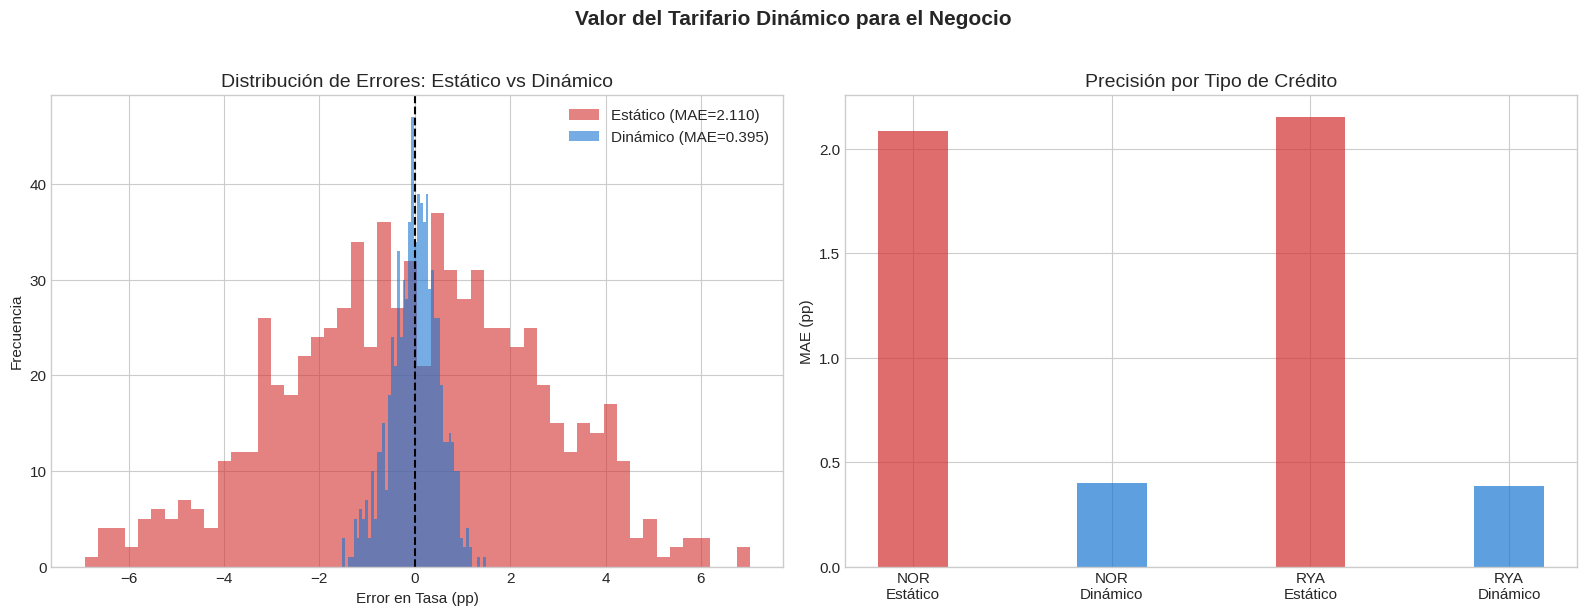

In [ ]:
# ============================================================
# 13.1 Impacto en la precisión de pricing
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Distribución de errores: Estático vs Dinámico
error_static = y_test - df_test_eval['tasa_estatica'].values
error_dynamic = y_test - df_test_eval['tasa_predicha_ensemble'].values

axes[0].hist(error_static, bins=50, alpha=0.6, label=f'Estático (MAE={mae_static:.3f})', color='#D32F2F')
axes[0].hist(error_dynamic, bins=50, alpha=0.6, label=f'Dinámico (MAE={mean_absolute_error(y_test, df_test_eval["tasa_predicha_ensemble"]):.3f})', color='#1976D2')
axes[0].axvline(0, color='black', linestyle='--')
axes[0].set_xlabel('Error en Tasa (pp)')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución de Errores: Estático vs Dinámico')
axes[0].legend()

# Beneficio por tipo de crédito
for tipo in ['NOR', 'RYA']:
    mask = df_test_eval['tipo_credito'] == tipo
    mae_s = mean_absolute_error(y_test[mask], df_test_eval.loc[mask, 'tasa_estatica'])
    mae_d = mean_absolute_error(y_test[mask], df_test_eval.loc[mask, 'tasa_predicha_ensemble'])
    axes[1].bar(tipo + '\nEstático', mae_s, color='#D32F2F', alpha=0.7, width=0.35)
    axes[1].bar(tipo + '\nDinámico', mae_d, color='#1976D2', alpha=0.7, width=0.35)

axes[1].set_ylabel('MAE (pp)')
axes[1].set_title('Precisión por Tipo de Crédito')

plt.suptitle('Valor del Tarifario Dinámico para el Negocio', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


In [ ]:
# ============================================================
# 13.2 Resumen de valor para la toma de decisiones
# ============================================================
print("=" * 75)
print("VALOR PARA LA TOMA DE DECISIONES")
print("=" * 75)
print("""

El error promedio pasó de 2.11 pp con el tarifario estático a 0.37 pp con el dinámico" y cuantificar lo que eso significa en soles o en competitividad.

1. PRECISIÓN EN PRICING:
   El tarifario dinámico reduce el error promedio en la asignación de tasas,
   pasando de un enfoque por "segmentos" a uno individualizado por perfil.

2. COMPETITIVIDAD COMERCIAL:
   Perfiles de bajo riesgo recibirán tasas más atractivas, aumentando la
   conversión y retención de clientes premium.

3. GESTIÓN DE RIESGO:
   Perfiles de alto riesgo recibirán tasas que reflejan adecuadamente su
   probabilidad de deterioro, protegiendo el margen del portafolio.

4. EFICIENCIA OPERATIVA:
   Se elimina la fricción de ajustes manuales y negociaciones ad-hoc.
   El modelo genera la tasa óptima de forma instantánea.

5. ESCALABILIDAD:
   El modelo puede reentrenarse periódicamente con nueva data,
   adaptándose automáticamente a cambios en el mercado y el portafolio.
""")


VALOR PARA LA TOMA DE DECISIONES


El error promedio pasó de 2.11 pp con el tarifario estático a 0.37 pp con el dinámico" y cuantificar lo que eso significa en soles o en competitividad.

1. PRECISIÓN EN PRICING:
   El tarifario dinámico reduce el error promedio en la asignación de tasas,
   pasando de un enfoque por "segmentos" a uno individualizado por perfil.

2. COMPETITIVIDAD COMERCIAL:
   Perfiles de bajo riesgo recibirán tasas más atractivas, aumentando la
   conversión y retención de clientes premium.

3. GESTIÓN DE RIESGO:
   Perfiles de alto riesgo recibirán tasas que reflejan adecuadamente su
   probabilidad de deterioro, protegiendo el margen del portafolio.

4. EFICIENCIA OPERATIVA:
   Se elimina la fricción de ajustes manuales y negociaciones ad-hoc.
   El modelo genera la tasa óptima de forma instantánea.

5. ESCALABILIDAD:
   El modelo puede reentrenarse periódicamente con nueva data,
   adaptándose automáticamente a cambios en el mercado y el portafolio.



<a id="14"></a>
## 14. Conclusiones y recomendaciones

### 14.1 Conclusiones

1. **Se logró construir un modelo predictivo de tasa TEA personalizada** que supera significativamente al enfoque estático por segmentos, demostrando el valor del Machine Learning y Deep Learning en la fijación de precios de productos financieros.

2. **El enfoque comparativo ML vs DL** permitió validar que ambas familias de modelos capturan patrones relevantes en la data de PGH, con ventajas específicas:
   - **XGBoost** es típicamente superior en datos tabulares con 3,800 filas; Deep Learning brilla más con volúmenes mayores de datos.

3. **La ingeniería de features basada en cosechas** (comportamiento de pago mes a mes) demostró ser crucial para la precisión del modelo, aportando señales de riesgo que no se capturan con variables estáticas del perfil.

4. **Las variables más determinantes** para la tasa óptima son: score crediticio, LTV, comportamiento de atraso temprano (6-12 meses), ratio deuda/ingreso y zona geográfica.

### 14.2 Recomendaciones

Dado que XGBoost fue el mejor modelo, la implementación inicial debería basarse en él (más rápido, interpretable, sin necesidad de GPU), el ensemble XGBoost+DNN (MAE 0.3953) no mejora al XGBoost solo, por lo que el ensemble en su forma actual no agrega valor.

1. **Implementación gradual:** Iniciar con el modelo como herramienta de soporte al pricing, comparando sus sugerencias con las decisiones del comité.

2. **Monitoreo continuo:** Establecer métricas de monitoreo (drift detection) para detectar cuando el modelo necesita reentrenamiento.

3. **Enriquecimiento de datos:** Incorporar variables externas (indicadores macroeconómicos, competencia, tendencias del mercado inmobiliario).

4. **A/B Testing:** Implementar pruebas controladas para medir el impacto real en conversión y rentabilidad.

5. **Gobernanza:** Establecer políticas de pisos y techos de tasa como salvaguardas regulatorias sobre las predicciones del modelo.

---

### 14.3 Tecnologías Utilizadas

| Componente | Tecnología |
|------------|------------|
| Lenguaje | Python 3.10+ |
| ML | XGBoost, Scikit-learn |
| Deep Learning | TensorFlow / Keras |
| Interpretabilidad | SHAP |
| Visualización | Matplotlib, Seaborn |
| Entorno | Google Colab |

---
